# Load Data

In [ ]:
import glob
import pickle

In [ ]:
AKE_dtm_dict = {}

file_list = glob.glob('*_dtm_dict.pkl')

for file_name in file_list:
    dataset_name = file_name.replace('_dtm_dict.pkl', '')

    with open(file_name, 'rb') as f:
        dtm_dict = pickle.load(f)

    cleaned_dtm_dict = {
        key.replace(f"{dataset_name}_", ""): dtm
        for key, dtm in dtm_dict.items()
    }

    AKE_dtm_dict[dataset_name] = cleaned_dtm_dict

# Integrity Pretest

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
!pip install POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.3 MB/s eta 0:00:00


In [ ]:
import ot

In [ ]:
class TTM_dict_builder:
    def __init__(self, AKE_dtm_dict):
        self.AKE_dtm_dict = AKE_dtm_dict
        self.TTM_dict = {}

    def build_ttms(self, edge_measures):

        for dataset_name, methods in self.AKE_dtm_dict.items():
            self.TTM_dict[dataset_name] = {}

            for method_name, dtm in methods.items():
                self.TTM_dict[dataset_name][method_name] = {}

                for measure in edge_measures:
                    calc_func = getattr(self, f"build_{measure}_ttm")
                    self.TTM_dict[dataset_name][method_name][measure] = calc_func(dtm)

        return self.TTM_dict

    def build_CF_ttm(self, dtm):
        binary_dtm = (dtm > 0).astype(int)
        cf_matrix = binary_dtm.T.dot(binary_dtm)
        return cf_matrix

    def build_Dice_ttm(self, dtm):
        cf_matrix = self.build_CF_ttm(dtm)
        diag = np.diag(cf_matrix)
        i_diag = diag[:, np.newaxis]
        j_diag = diag[np.newaxis, :]
        dice_matrix = 2 * cf_matrix / (i_diag + j_diag)
        np.fill_diagonal(dice_matrix.values, 1.0)
        return pd.DataFrame(dice_matrix, index=cf_matrix.index, columns=cf_matrix.columns)

    def build_Jaccard_ttm(self, dtm):
        cf_matrix = self.build_CF_ttm(dtm)
        diag = np.diag(cf_matrix)
        i_diag = diag[:, np.newaxis]
        j_diag = diag[np.newaxis, :]
        denominator = i_diag + j_diag - cf_matrix
        jaccard_matrix = cf_matrix / denominator
        np.fill_diagonal(jaccard_matrix.values, 1.0)
        return pd.DataFrame(jaccard_matrix, index=cf_matrix.index, columns=cf_matrix.columns)

    def build_Cosine_ttm(self, dtm):
        term_vectors = dtm.T
        similarity_matrix = term_vectors.dot(term_vectors.T)
        norms = (term_vectors ** 2).sum(axis=1) ** 0.5
        return similarity_matrix.divide(norms, axis=0).divide(norms, axis=1)

    def build_Euclidean_ttm(self, dtm):
        term_vectors = dtm.T.values
        term_names = dtm.columns
        dist_matrix = np.zeros((len(term_vectors), len(term_vectors)))

        for i in range(len(term_vectors)):
            for j in range(i + 1, len(term_vectors)):
                dist = np.sqrt(np.sum((term_vectors[i] - term_vectors[j]) ** 2))
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist

        max_dist = np.max(dist_matrix)
        similarity_matrix = 1 - (dist_matrix / max_dist)
        return pd.DataFrame(similarity_matrix, index=term_names, columns=term_names)

    def build_DMD_ttm(self, dtm):
            dtm_values = dtm.values
            m, n = dtm_values.shape

            cost_matrix = np.zeros((m, m))

            for k in range(m):
                for l in range(k + 1, m):
                    dist = np.sqrt(np.sum((dtm_values[k] - dtm_values[l]) ** 2))
                    cost_matrix[k, l] = dist
                    cost_matrix[l, k] = dist

            term_vectors = dtm_values.T
            dmd_matrix = np.zeros((n, n))

            for i in range(n):
                for j in range(i, n):
                    p_norm = term_vectors[i] / np.sum(term_vectors[i])
                    q_norm = term_vectors[j] / np.sum(term_vectors[j])

                    dmd = ot.emd2(p_norm, q_norm, cost_matrix)

                    dmd_matrix[i, j] = dmd
                    dmd_matrix[j, i] = dmd

            max_dist = np.max(dmd_matrix)
            sim_matrix = 1 - (dmd_matrix / max_dist)

            return pd.DataFrame(sim_matrix, index=dtm.columns, columns=dtm.columns)

In [ ]:
TTM_dict = TTM_dict_builder(AKE_dtm_dict).build_ttms(['CF', 'Dice', 'Jaccard', 'Cosine', 'Euclidean', 'DMD'])

In [ ]:
with open("TTM_dict.pkl", "wb") as f:
    pickle.dump(TTM_dict, f)

In [ ]:
def compute_MCC(y_true, y_pred):

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    numerator = (tp * tn) - (fp * fn)

    denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

    if denominator == 0:
        if np.array_equal(y_true, y_pred):
            return 1.0
        else:
            return 0.0

    return numerator / denominator

def run_integrity_pretest(AKE_ttm_dict):
    results = []

    for dataset_name, methods in AKE_ttm_dict.items():
        for method_name, measures in methods.items():
            cf_ttm = measures['CF']
            n = cf_ttm.shape[0]
            tril_indices = np.tril_indices(n, k=-1)

            y_true = (cf_ttm.values[tril_indices] > 0).astype(int)

            for measure_name, ttm_df in measures.items():
                test_values = ttm_df.values[tril_indices]

                y_pred = (test_values > 0).astype(int)

                mcc_score = compute_MCC(y_true, y_pred)

                results.append({
                    'Dataset': dataset_name,
                    'Method': method_name,
                    'Measure': measure_name,
                    'MCC': mcc_score
                })

    return pd.DataFrame(results)

In [ ]:
test_result_df = run_integrity_pretest(TTM_dict)

In [ ]:
test_result_df['Passed'] = (test_result_df['MCC'] == 1.0).astype(int)

test_summary_df = test_result_df.groupby(['Dataset', 'Measure']).agg(
    success=('Passed', 'sum'),
    total=('Passed', 'count')
).reset_index()

test_summary_df['Ratio'] = test_summary_df.apply(lambda x: f"{x['success']}/{x['total']}", axis=1)

test_summary_table = test_summary_df.pivot(index='Dataset', columns='Measure', values='Ratio')

In [ ]:
test_summary_table

Measure,CF,Cosine,DMD,Dice,Euclidean,Jaccard
Dataset,,,,,,
500N-KP-Crowd,8/8,8/8,0/8,8/8,0/8,8/8
DUC-2001,8/8,8/8,0/8,8/8,0/8,8/8
Inspec,8/8,8/8,0/8,8/8,0/8,8/8
KDD,10/10,10/10,0/10,10/10,0/10,10/10
NUS,8/8,8/8,1/8,8/8,0/8,8/8
SemEval-2010,8/8,8/8,0/8,8/8,0/8,8/8
SemEval-2017,10/10,10/10,0/10,10/10,0/10,10/10
WWW,8/8,8/8,0/8,8/8,0/8,8/8


# Build SNs

In [ ]:
import networkx as nx

In [ ]:
def build_semantic_network(ttm, omega=100):
    nodes = ttm.columns.tolist()
    l = len(nodes)

    edges = []
    for i in range(l):
        for j in range(i + 1, l):
            weight = ttm.iloc[i, j]
            if weight > 0:
                edges.append((nodes[i], nodes[j], weight))

    edges.sort(key=lambda x: x[2], reverse=True)

    G = nx.Graph()
    G.add_nodes_from(nodes)

    G_temp = nx.Graph()
    G_temp.add_nodes_from(nodes)
    G_temp.add_weighted_edges_from(edges)

    mst = nx.maximum_spanning_tree(G_temp, weight='weight')

    current_edges = set()
    for u, v in mst.edges():
        current_edges.add(tuple(sorted((u, v))))

    G.add_weighted_edges_from([(u, v, d['weight']) for u, v, d in mst.edges(data=True)])

    for u, v, w in edges:
        if G.number_of_edges() >= omega:
            break

        edge_tuple = tuple(sorted((u, v)))
        if edge_tuple not in current_edges:
            G.add_edge(u, v, weight=w)
            current_edges.add(edge_tuple)

    return G

In [ ]:
def build_graph_dict(ttm_dict, omega=100):
    graph_dict = {}
    excluded_measures = {'Euclidean', 'DMD'}

    for dataset, methods in ttm_dict.items():
        graph_dict[dataset] = {}

        for method, measures in methods.items():
            graph_dict[dataset][method] = {}

            for measure, ttm_df in measures.items():
                if measure in excluded_measures:
                    continue

                graph_dict[dataset][method][measure] = build_semantic_network(ttm_df, omega=omega)

    return graph_dict

In [ ]:
Graph_dict = build_graph_dict(TTM_dict, omega=100)

In [ ]:
with open("Graph_dict.pkl", "wb") as f:
    pickle.dump(Graph_dict, f)

# Build Null Models

In [ ]:
import random

In [ ]:
def algorithm2(G_orig, h=10000, z=1.0, seed=2026):
    random.seed(seed)

    T_orig = nx.transitivity(G_orig)
    L_orig = nx.average_shortest_path_length(G_orig)

    T_upper = T_orig * (1 + z)
    L_upper = L_orig * (1 + z)

    G_null = G_orig.copy()

    curr_T = T_orig
    curr_L = L_orig

    potential_nodes = [n for n in G_null.nodes() if G_null.degree(n) > 1]

    for i in range(h):

        found_valid_triad = False

        while not found_valid_triad:
            v_a = random.choice(potential_nodes)

            neighbors_a = [n for n in G_null.neighbors(v_a) if G_null.degree(n) > 1]

            if len(neighbors_a) >= 2:
                v_b, v_c = random.sample(neighbors_a, 2)

                neighbors_b = [n for n in G_null.neighbors(v_b) if n != v_a]
                neighbors_c = [n for n in G_null.neighbors(v_c) if n != v_a]

                if neighbors_b and neighbors_c:
                    v_d = random.choice(neighbors_b)
                    v_e = random.choice(neighbors_c)

                    if v_d != v_e:
                        found_valid_triad = True

        if not (G_null.has_edge(v_b, v_c) or G_null.has_edge(v_d, v_e)):
            G_null.remove_edge(v_b, v_d)
            G_null.remove_edge(v_c, v_e)
            G_null.add_edge(v_b, v_c)
            G_null.add_edge(v_d, v_e)

            is_valid = False

            if nx.is_connected(G_null):
                new_T = nx.transitivity(G_null)
                new_L = nx.average_shortest_path_length(G_null)

                if (new_T <= T_upper and new_L <= L_upper) and (new_T > curr_T and new_L > curr_L):
                    curr_T, curr_L = new_T, new_L
                    is_valid = True

                    if (curr_T >= 0.95 * T_upper) and (curr_L >= 0.95 * L_upper):
                        return G_null

            if not is_valid:
                G_null.add_edge(v_b, v_d)
                G_null.add_edge(v_c, v_e)
                G_null.remove_edge(v_b, v_c)
                G_null.remove_edge(v_d, v_e)

    return G_null

In [ ]:
def build_null_graph_dict(graph_dict, h=10000, z=1.0, seed=2026):
    null_graph_dict = {}

    for dataset, methods in graph_dict.items():
        for method, measures in methods.items():
            for measure, G_orig in measures.items():

                if nx.is_connected(G_orig):
                    G_null = algorithm2(G_orig, h=h, z=z, seed=seed)

                    null_graph_dict.setdefault(dataset, {}).setdefault(method, {})[measure] = G_null

    return null_graph_dict

In [ ]:
Null_Graph_dict = build_null_graph_dict(Graph_dict, h=10000, z=1.0, seed=2026)

In [ ]:
with open("Null_Graph_dict.pkl", "wb") as f:
    pickle.dump(Null_Graph_dict, f)

# Vertex Random Failure Simulations

In [ ]:
def calculate_fc(G, runs=1000, seed=2026):
    random.seed(seed)
    V_size = G.number_of_nodes()
    fc_list = []

    for i in range(runs):
        G_copy = G.copy()
        node_list = list(G_copy.nodes())
        random.shuffle(node_list)

        max_c2_size = -1
        fc = 0

        for step, node in enumerate(node_list):
            G_copy.remove_node(node)
            all_ccs = list(nx.connected_components(G_copy))

            if len(all_ccs) < 2:
                current_c2_size = 0

            else:
                cc_sizes = sorted([len(c) for c in all_ccs], reverse=True)
                current_c2_size = cc_sizes[1]

            if current_c2_size > max_c2_size:
                max_c2_size = current_c2_size
                fc = (step + 1) / V_size

        fc_list.append(fc)

    return np.mean(fc_list)

In [ ]:
def calculate_ri_ip(graph_dict, null_graph_dict, runs=1000, seed=2026):
    results = []

    for dataset, methods in null_graph_dict.items():
        for method, measures in methods.items():
            for measure, G_null in measures.items():
                G_sn = graph_dict[dataset][method][measure]

                l_null = nx.average_shortest_path_length(G_null)
                l_sn = nx.average_shortest_path_length(G_sn)
                ip1 = (l_null - l_sn) / l_null

                t_null = nx.transitivity(G_null)
                t_sn = nx.transitivity(G_sn)
                ip2 = (t_null - t_sn) / (t_null)

                fc_sn = calculate_fc(G_sn, runs=runs, seed=seed)
                fc_null = calculate_fc(G_null, runs=runs, seed=seed)

                if fc_sn > fc_null:
                    ri = (fc_sn - fc_null) / (1 - fc_null)
                else:
                    ri = 0

                results.append({
                    'Dataset': dataset,
                    'Method': method,
                    'Measure': measure,
                    'IP1': ip1,
                    'IP2': ip2,
                    'RI': ri,
                })

    df_results = pd.DataFrame(results)

    return df_results

In [ ]:
Edge_Weighting_results = calculate_ri_ip(Graph_dict, Null_Graph_dict, runs=1000, seed=2026)

In [ ]:
Edge_Weighting_results

,Dataset,Method,Measure,IP1,IP2,RI
0,SemEval-2010,TF,CF,0.000000,0.000000,0.000000
1,SemEval-2010,TF,Dice,0.000000,0.000000,0.000000
2,SemEval-2010,TF,Jaccard,0.000000,0.000000,0.000000
3,SemEval-2010,TF,Cosine,0.000000,0.000000,0.000000
4,SemEval-2010,TfIdf,CF,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
263,SemEval-2017,KeyBERT,Cosine,0.284402,0.500000,0.271728
264,SemEval-2017,MDERANK,CF,0.086750,0.304965,0.010255
265,SemEval-2017,MDERANK,Dice,0.206127,0.500000,0.252661
266,SemEval-2017,MDERANK,Jaccard,0.206127,0.500000,0.252661


In [ ]:
with open("Edge_Weighting_results.pkl", "wb") as f:
    pickle.dump(Edge_Weighting_results, f)

# Summary

In [ ]:
summary = Edge_Weighting_results.groupby(['Dataset', 'Measure'])['RI'].agg(['mean', 'std'])

summary_unstacked = summary.unstack(level='Measure')

summary_table = summary_unstacked.stack(level=0, future_stack=True).reset_index()
summary_table.rename(columns={'level_1': 'Stat'}, inplace=True)

dataset_order = ['SemEval-2010', 'NUS', 'Inspec', 'KDD', 'WWW', 'SemEval-2017', 'DUC-2001', '500N-KP-Crowd']
summary_table['Dataset'] = pd.Categorical(summary_table['Dataset'], categories=dataset_order, ordered=True)
summary_table['Stat'] = pd.Categorical(summary_table['Stat'], categories=['mean', 'std'], ordered=True)

summary_table = summary_table.sort_values(['Dataset', 'Stat']).reset_index(drop=True)
summary_table_rounded = summary_table.round(3)

In [ ]:
summary_table_rounded

Measure,Dataset,Stat,CF,Cosine,Dice,Jaccard
0,SemEval-2010,mean,0.015,0.042,0.018,0.018
1,SemEval-2010,std,0.043,0.054,0.023,0.023
2,NUS,mean,0.000,0.056,0.034,0.034
3,NUS,std,0.000,0.060,0.058,0.058
4,Inspec,mean,0.049,0.168,0.146,0.146
5,Inspec,std,0.086,0.076,0.128,0.128
6,KDD,mean,0.030,0.162,0.085,0.085
7,KDD,std,0.064,0.116,0.125,0.125
8,WWW,mean,0.032,0.216,0.114,0.114
9,WWW,std,0.057,0.126,0.142,0.142


# Normality Test

In [ ]:
from scipy import stats

In [ ]:
targets = ['IP1', 'IP2', 'RI']
norm_results = []

for metric in targets:
    observations = Edge_Weighting_results[metric]

    z_scores = (observations - observations.mean()) / observations.std()

    stat, p_val = stats.kstest(z_scores, 'norm')

    norm_results.append({
        'Metric': metric,
        'K-S Stat': f"{stat:.4f}",
        'p-value': f"{p_val:.4e}",
        'Is_Normal': 'Yes' if p_val > 0.05 else 'No'
    })

norm_summary = pd.DataFrame(norm_results)

In [ ]:
norm_summary

,Metric,K-S Stat,p-value,Is_Normal
0,IP1,0.1595,1.9991e-06,No
1,IP2,0.1204,7.6443e-04,No
2,RI,0.1938,2.6938e-09,No


In [ ]:
import matplotlib.pyplot as plt

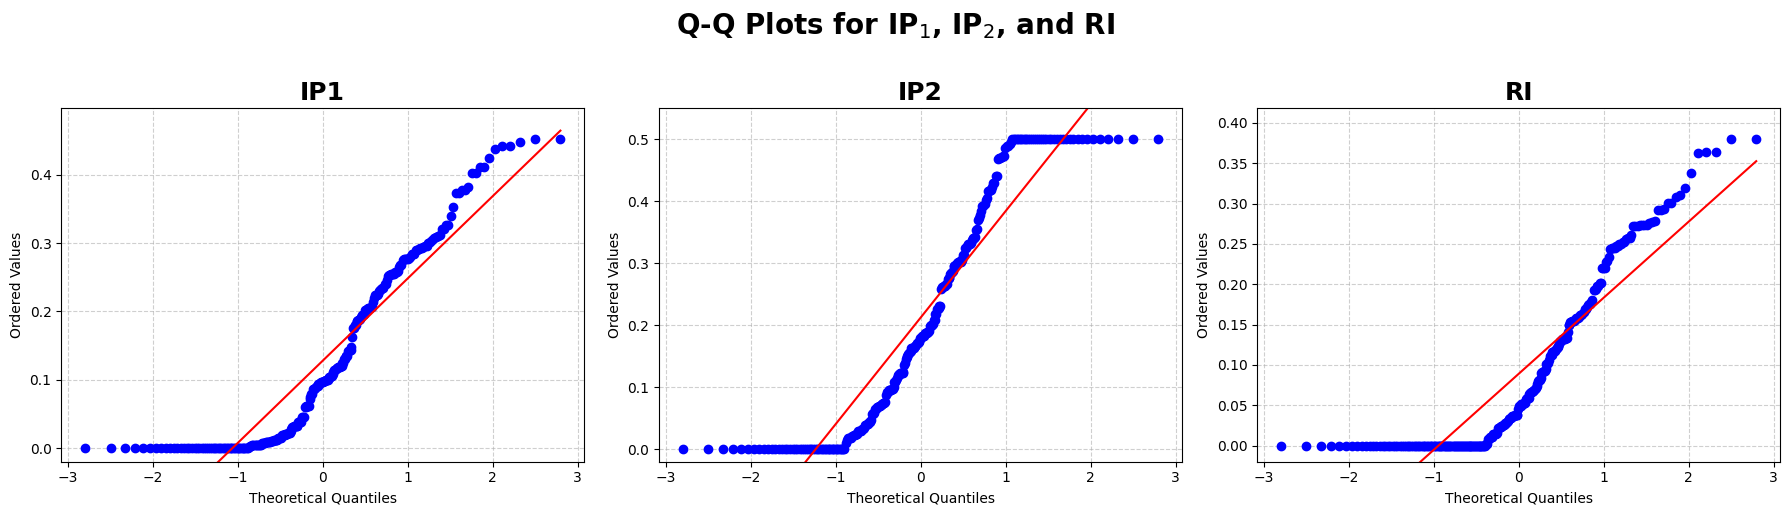

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), squeeze=False)
fig.suptitle("Q-Q Plots for IP$_{1}$, IP$_{2}$, and RI", fontsize=20, y=1.02, fontweight='bold')

axes_flat = axes.flatten()

for i, metric in enumerate(targets):
    ax = axes_flat[i]
    observations = Edge_Weighting_results[metric]

    stats.probplot(observations, dist="norm", plot=ax)

    ax.set_ylim(-0.02, max(observations) * 1.1)
    ax.grid(True, linestyle='--', alpha=0.6, zorder=0)

    ax.set_title(f"{metric}", fontsize=18, fontweight='semibold')
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Ordered Values")

plt.tight_layout()
plt.show()

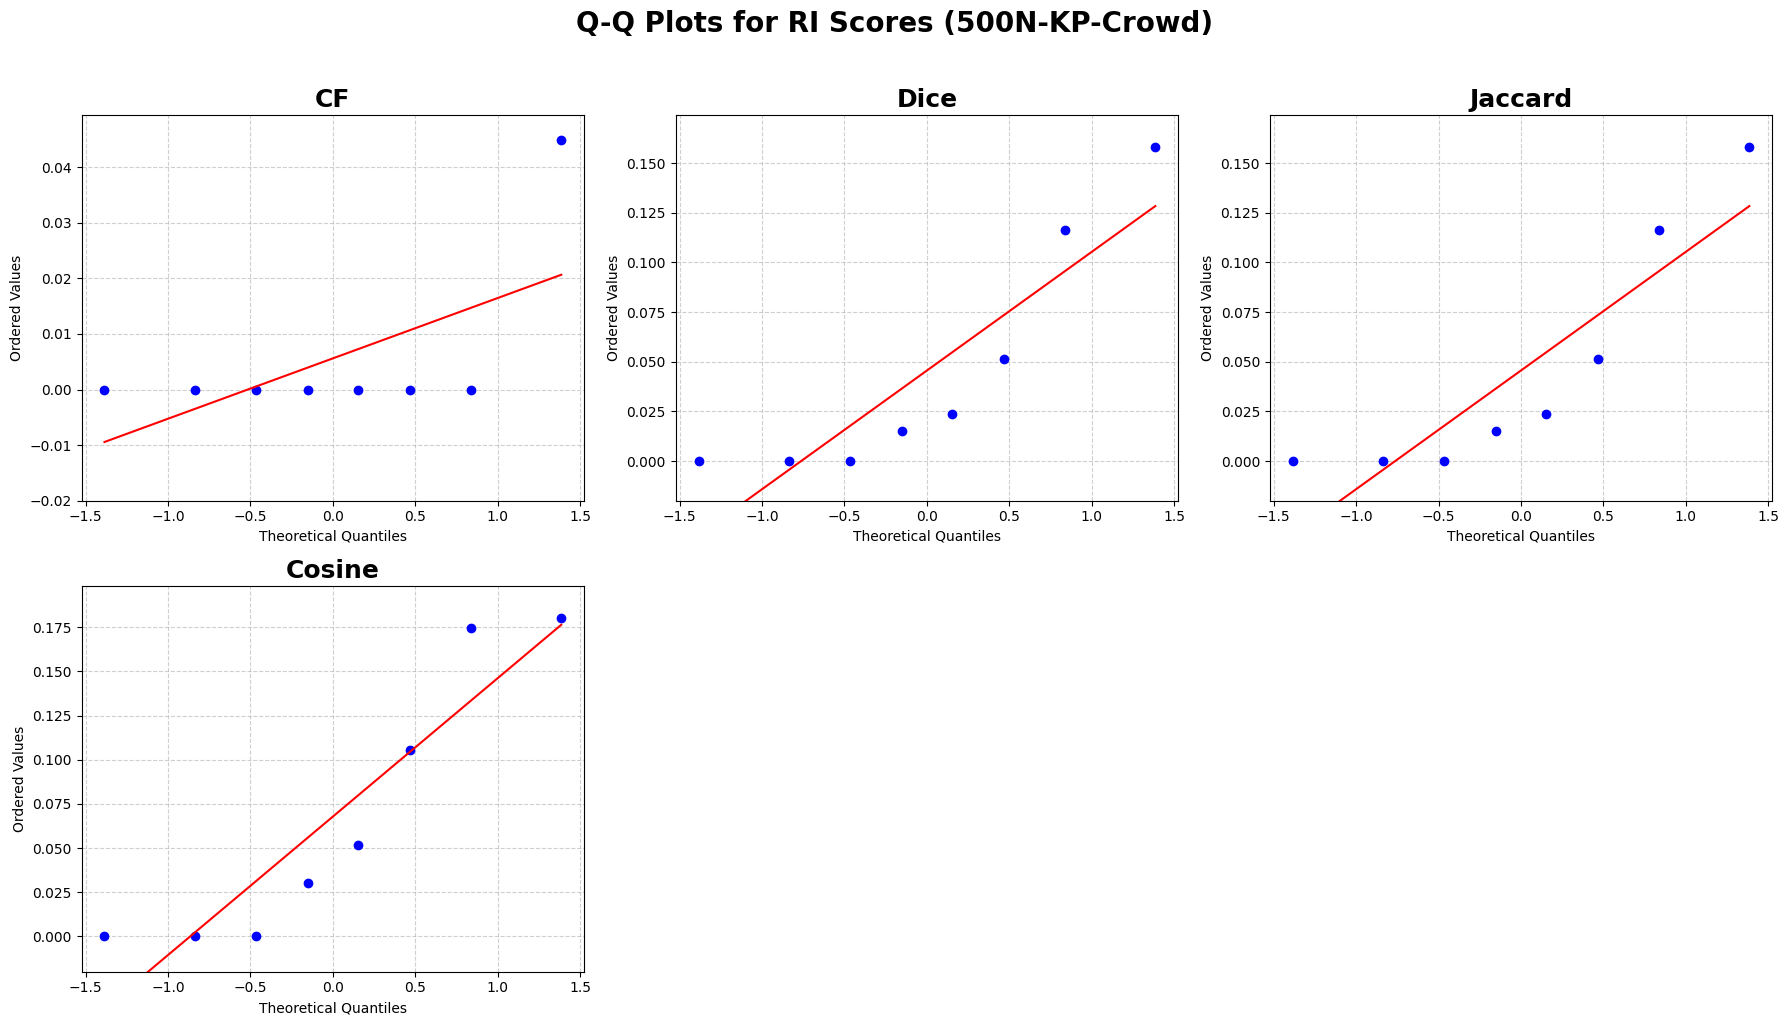

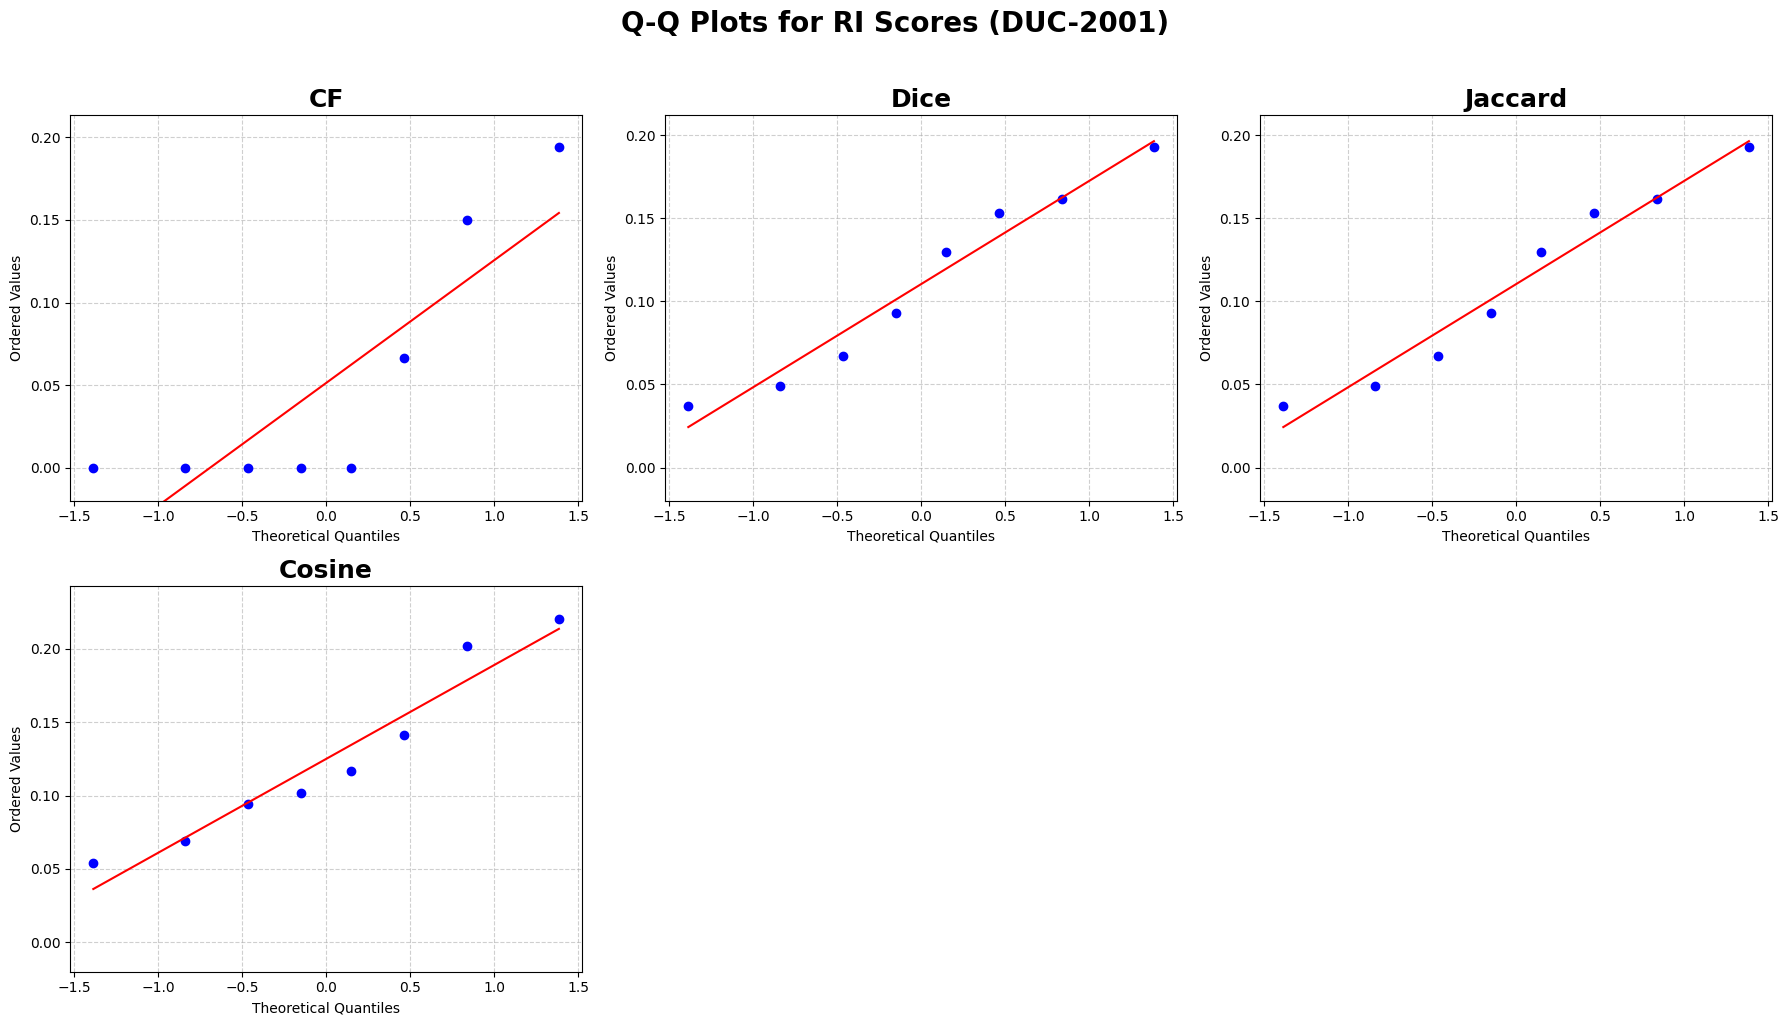

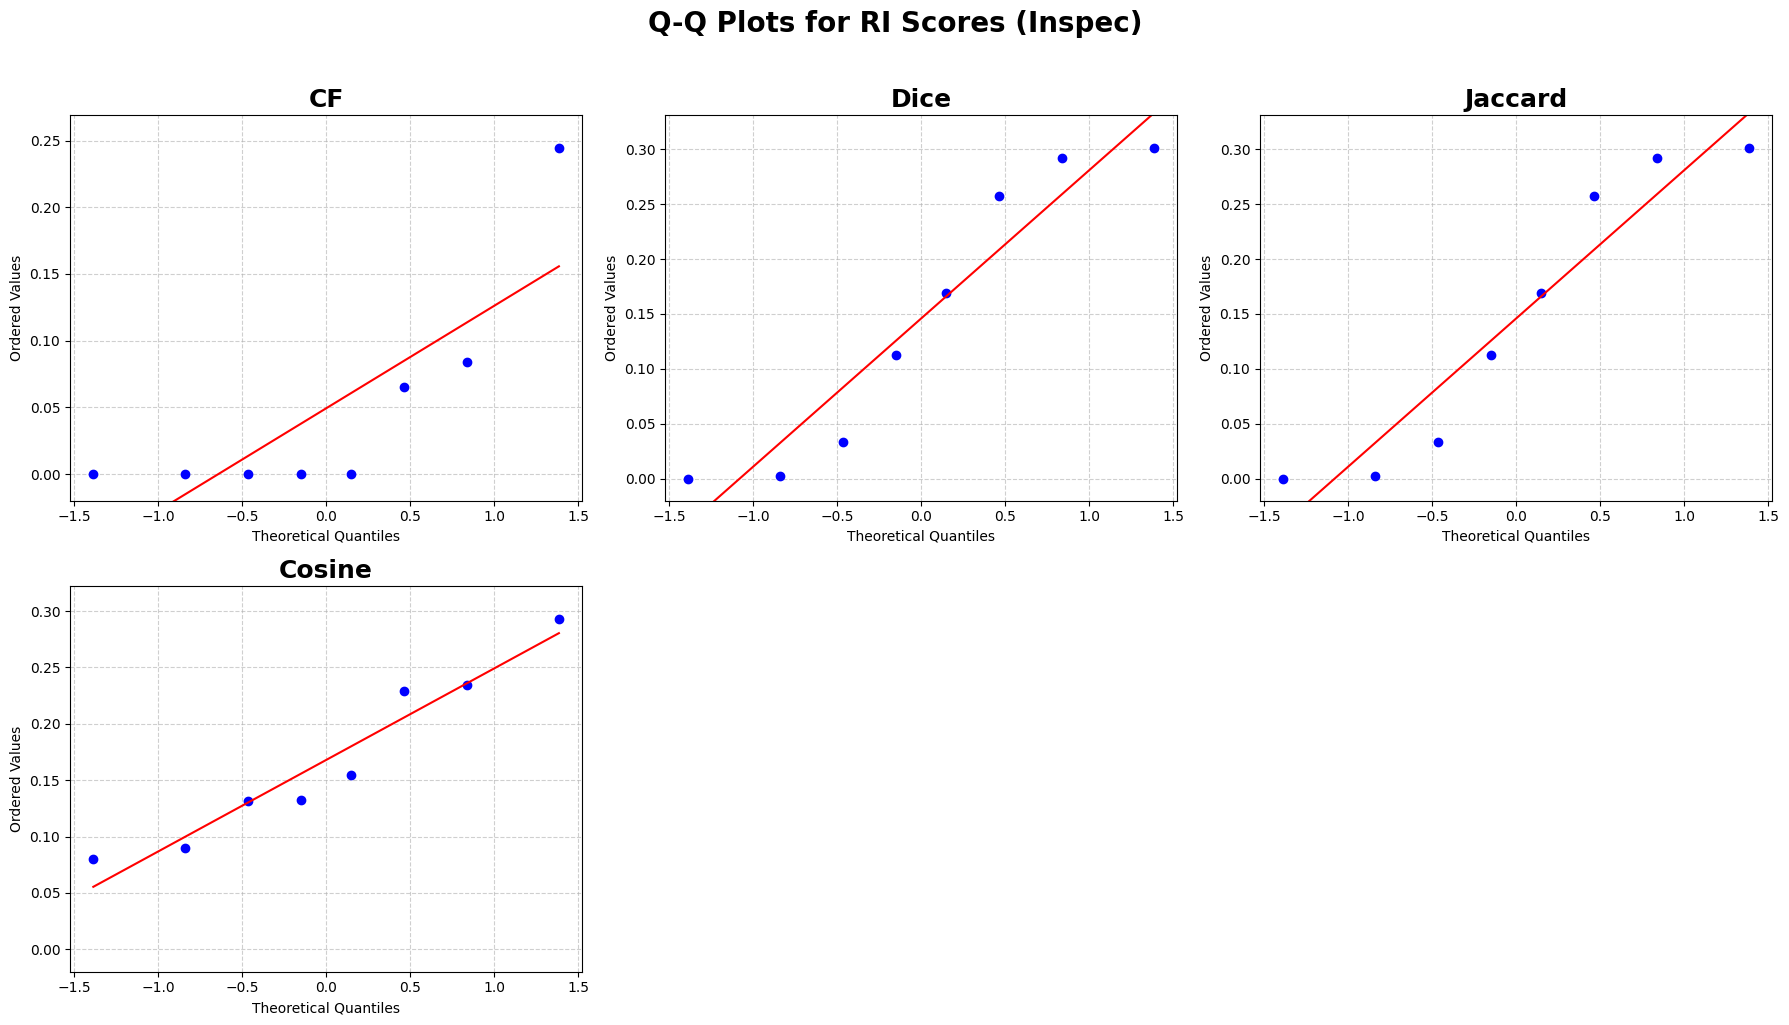

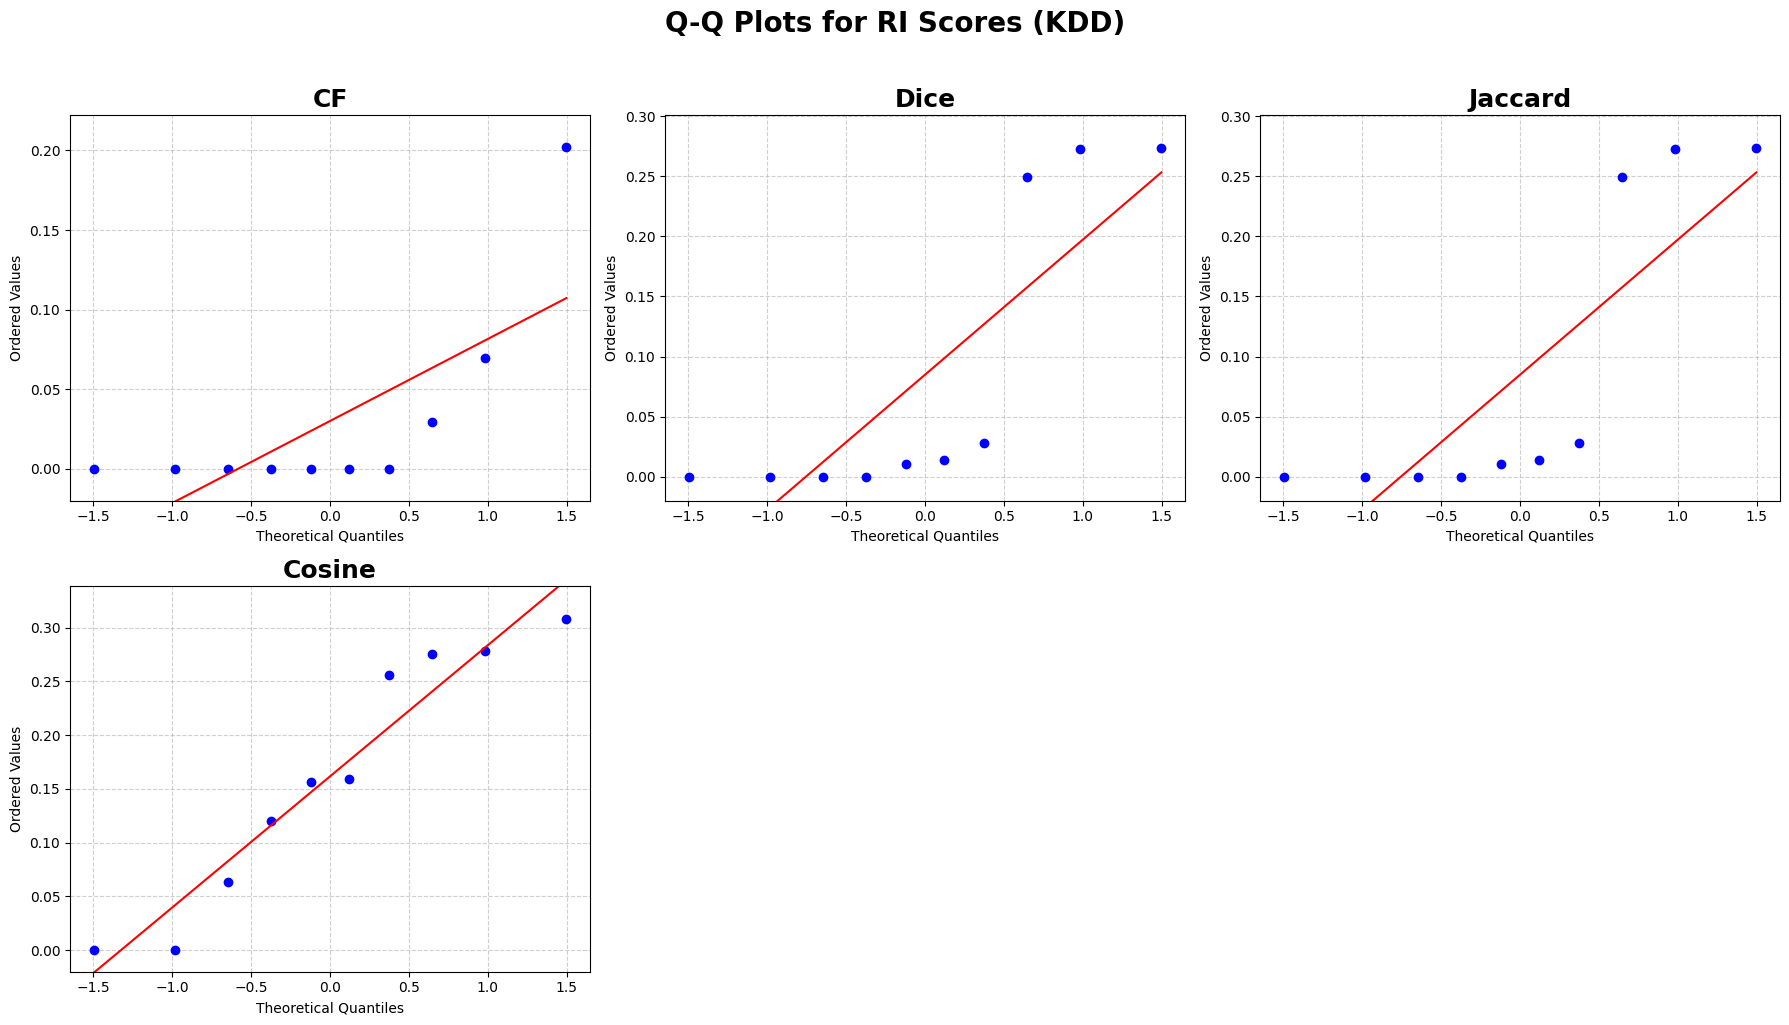

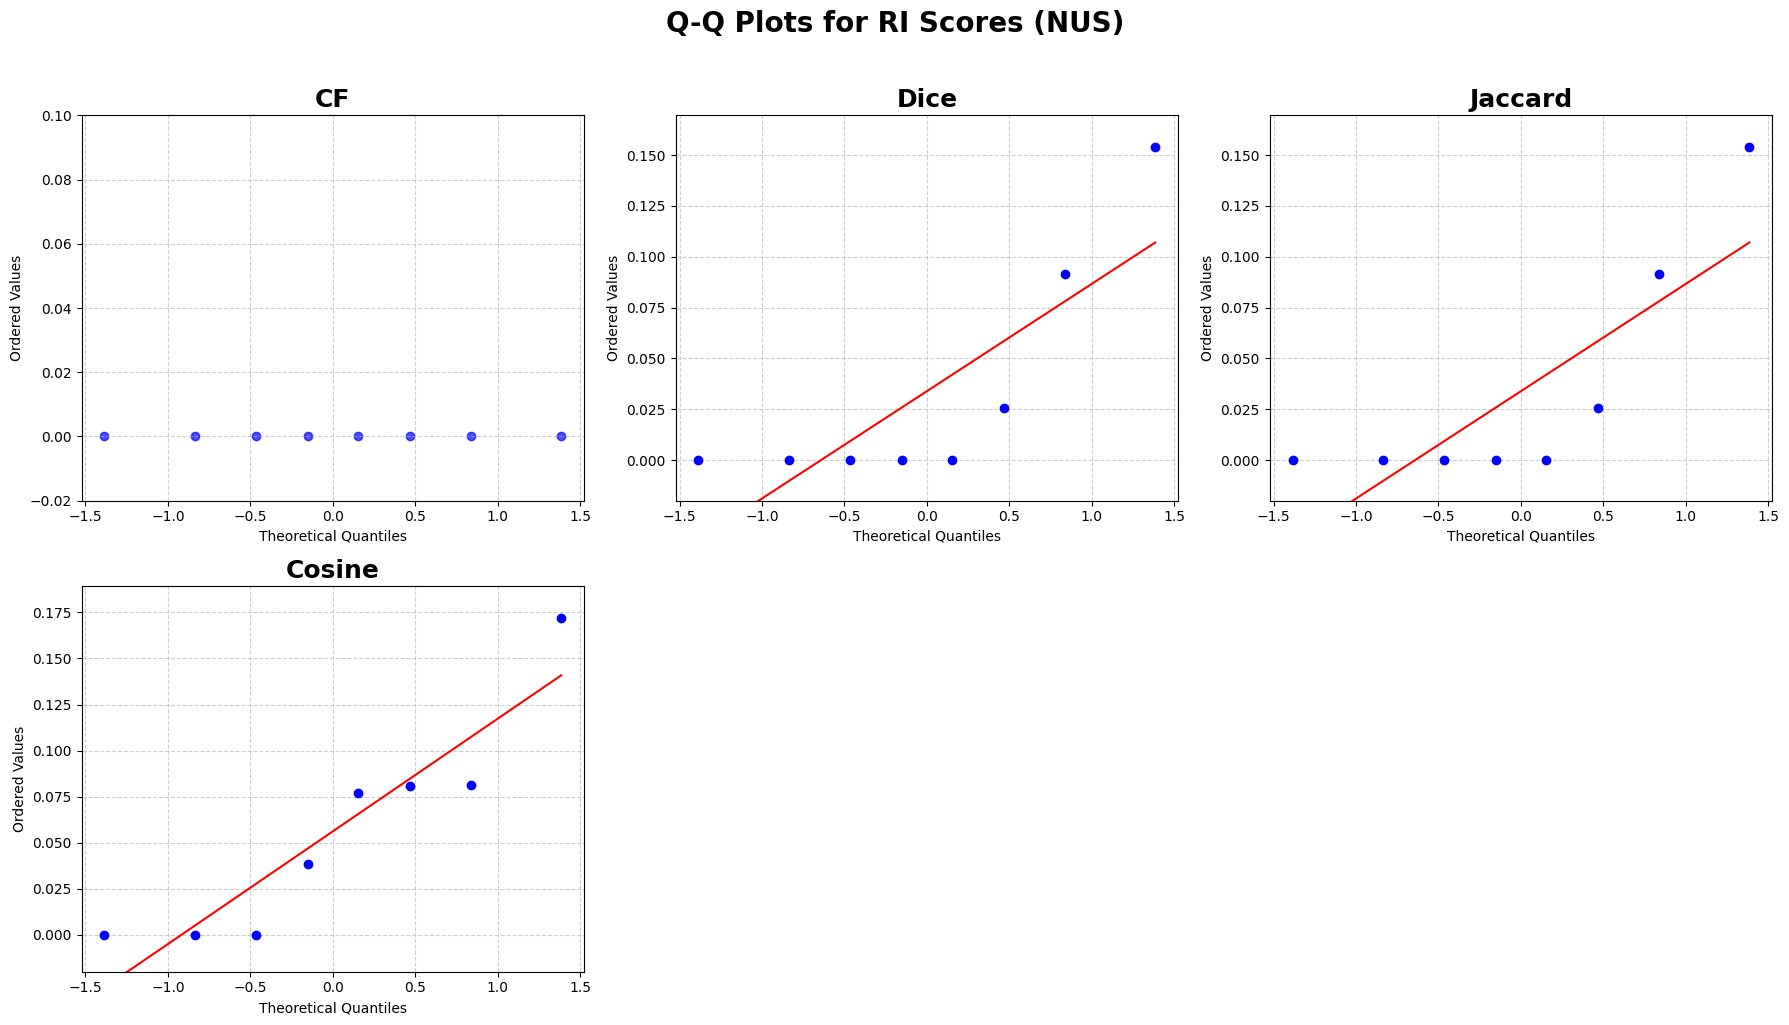

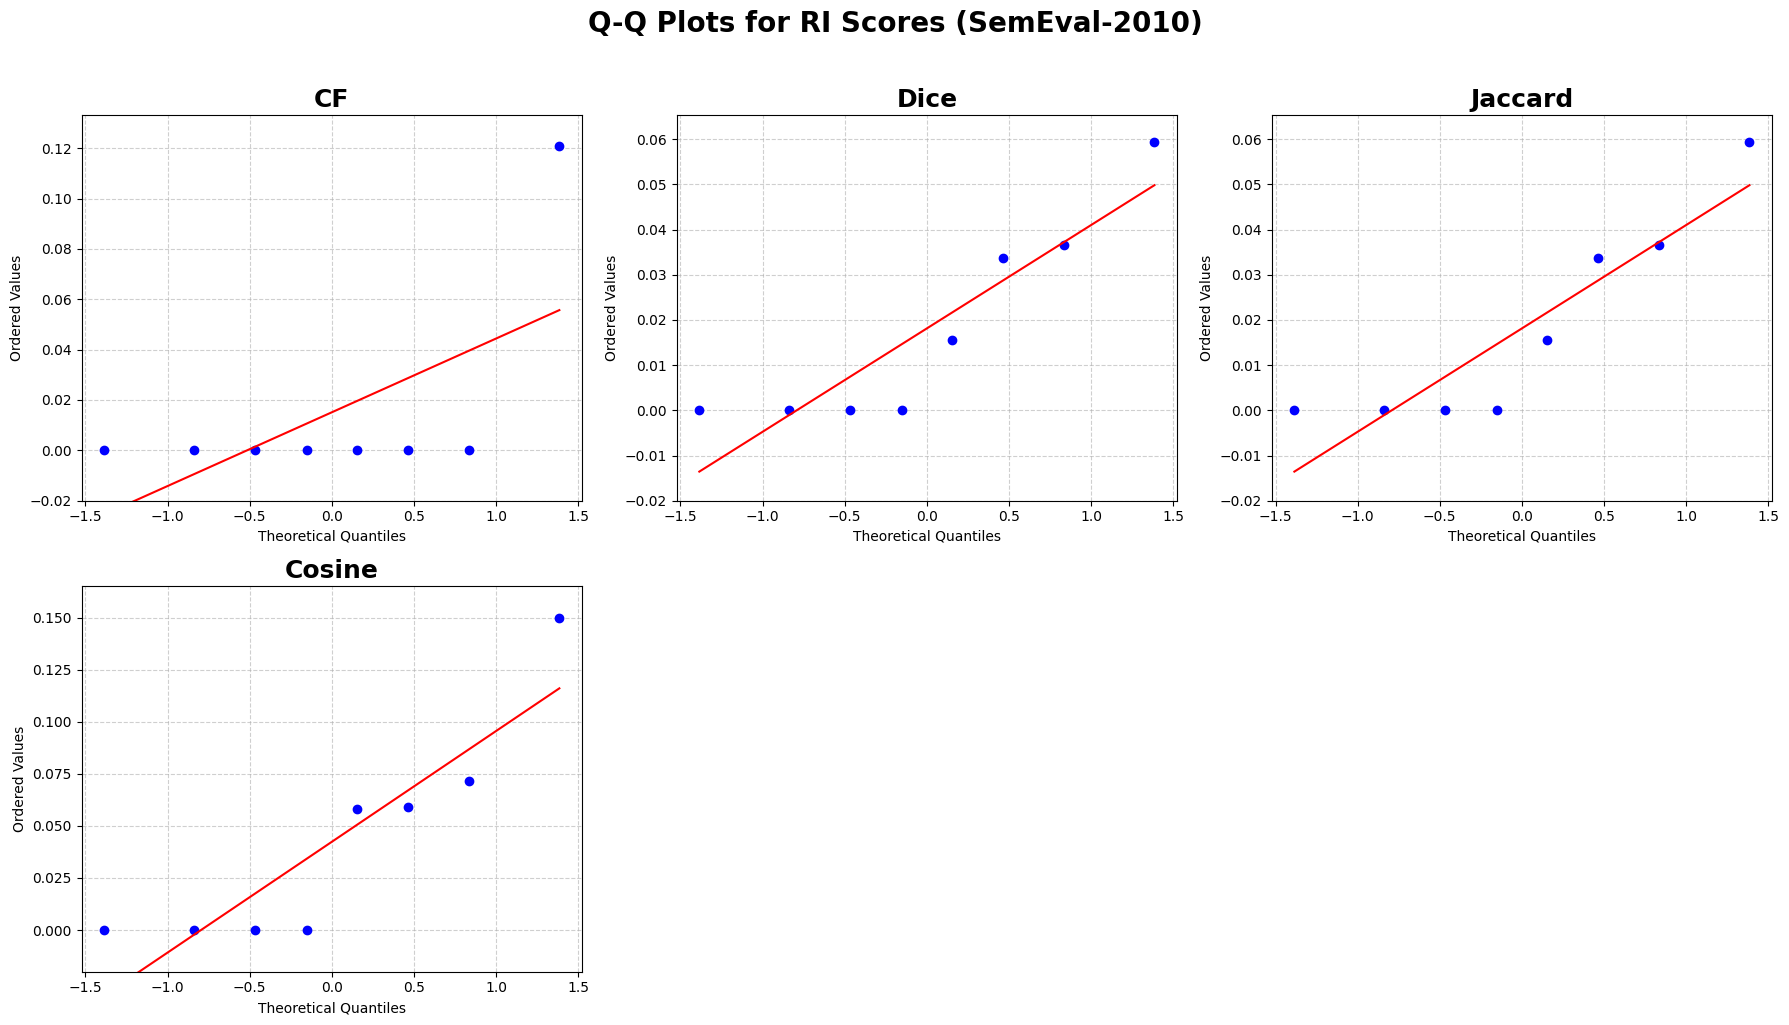

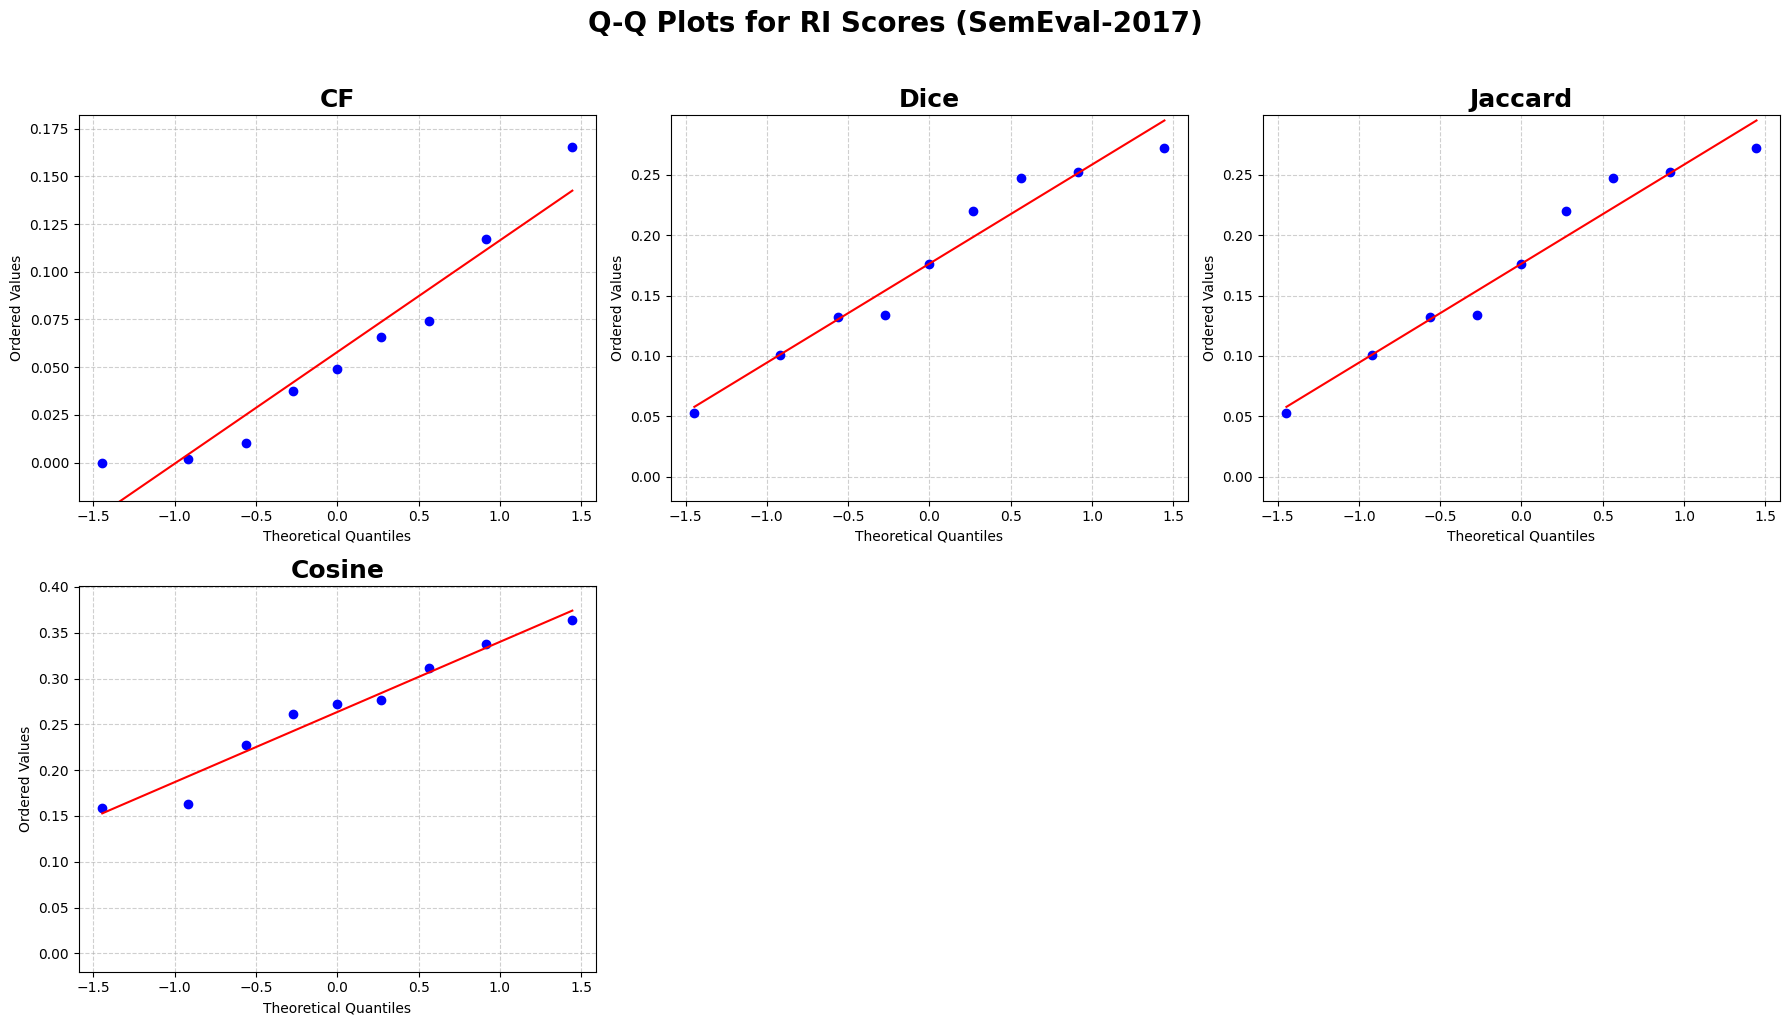

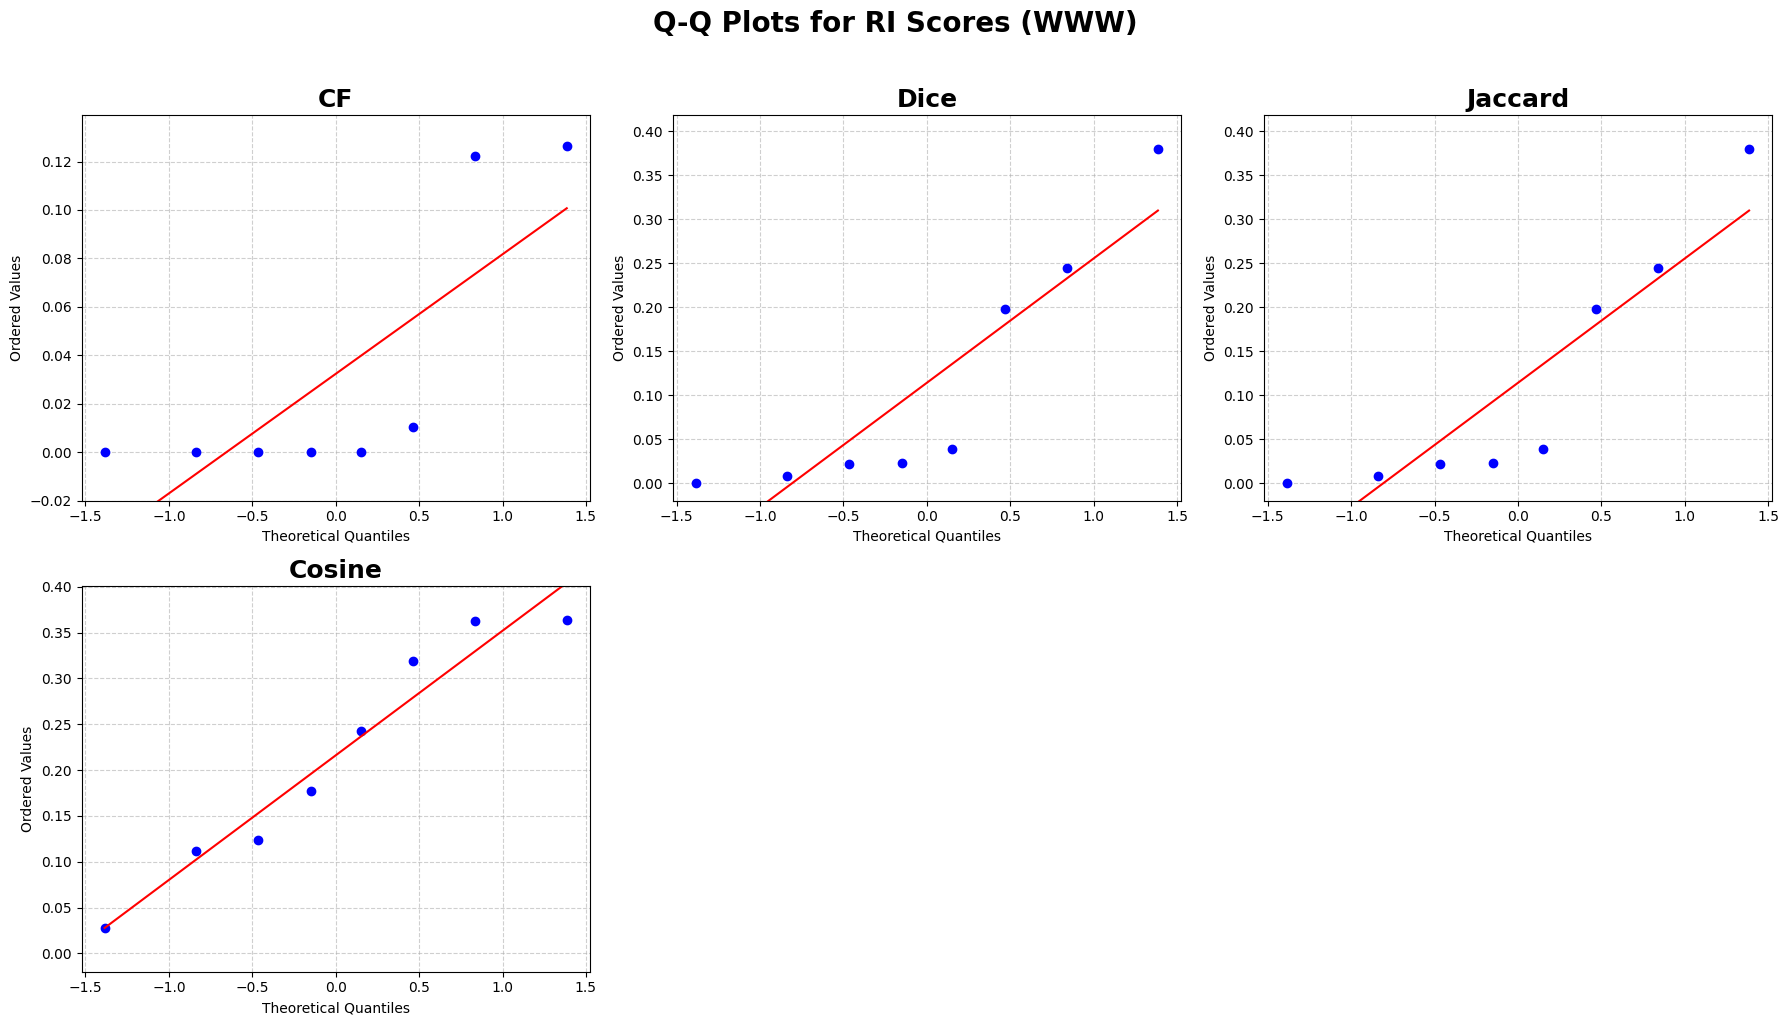

In [ ]:
for dataset, group in Edge_Weighting_results.groupby('Dataset'):
    measures = group['Measure'].unique()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), squeeze=False)
    fig.suptitle(f"Q-Q Plots for RI Scores ({dataset})", fontsize=20, y=1.02, fontweight='bold')

    axes_flat = axes.flatten()

    for i, measure in enumerate(measures):
        ax = axes_flat[i]
        observations = group[group['Measure'] == measure]['RI']

        if observations.nunique() < 2:
            osm, osr = stats.probplot(observations, dist="norm", fit=False)
            ax.scatter(osm, osr, color='blue', alpha=0.7)
        else:
            stats.probplot(observations, dist="norm", plot=ax)

        ax.set_ylim(-0.02, max(observations) * 1.1 if max(observations) > 0 else 0.1)
        ax.grid(True, linestyle='--', alpha=0.6, zorder=0)

        ax.set_title(f"{measure}", fontsize=18, fontweight='semibold')
        ax.set_xlabel("Theoretical Quantiles")
        ax.set_ylabel("Ordered Values")

    for j in range(4, 6):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

# 95% Bootstrap Confidence Inteval

In [ ]:
def get_bootstrap_ci(observations, n_bootstrap=10000, ci=95, seed=2026):
    scores = observations.values
    n = len(scores)

    original_mean = np.mean(scores)

    rng = np.random.default_rng(seed)
    resamples = rng.choice(scores, size=(n_bootstrap, n), replace=True)
    resampled_means = resamples.mean(axis=1)

    bootstrap_mean = np.mean(resampled_means)

    bootstrap_bias = bootstrap_mean - original_mean

    lower = np.percentile(resampled_means, (100 - ci) / 2)
    upper = np.percentile(resampled_means, 100 - (100 - ci) / 2)

    return original_mean, bootstrap_mean, lower, upper, bootstrap_bias

In [ ]:
ci_results = []

all_measures = Edge_Weighting_results['Measure'].unique()

for dataset in dataset_order:
    group = Edge_Weighting_results[Edge_Weighting_results['Dataset'] == dataset]

    for measure in all_measures:
        observations = group[group['Measure'] == measure]['RI']

        original_mean, bootstrap_mean, lower, upper, bootstrap_bias = get_bootstrap_ci(observations)
        ci_results.append({
            'Dataset': dataset,
            'Measure': measure,
            'Original Mean': original_mean,
            'Bootstrap Mean': bootstrap_mean,
            'CI Lower': lower,
            'CI Upper': upper,
            'Bootstrap Bias': bootstrap_bias
        })

ci_df = pd.DataFrame(ci_results)
ci_df['Dataset'] = pd.Categorical(ci_df['Dataset'], categories=dataset_order, ordered=True)
ci_df = ci_df.sort_values(['Dataset', 'Measure']).reset_index(drop=True)

In [ ]:
ci_df

,Dataset,Measure,Original Mean,Bootstrap Mean,CI Lower,CI Upper,Bootstrap Bias
0,SemEval-2010,CF,0.015118,0.015082,0.000000,0.045354,-0.000036
1,SemEval-2010,Cosine,0.042365,0.042333,0.008970,0.079865,-0.000032
2,SemEval-2010,Dice,0.018132,0.018151,0.004210,0.033540,0.000019
3,SemEval-2010,Jaccard,0.018132,0.018151,0.004210,0.033540,0.000019
4,NUS,CF,0.000000,0.000000,0.000000,0.000000,0.000000
5,NUS,Cosine,0.056146,0.056195,0.019729,0.098049,0.000049
6,NUS,Dice,0.033878,0.033750,0.000000,0.076013,-0.000129
7,NUS,Jaccard,0.033878,0.033750,0.000000,0.076013,-0.000129
8,Inspec,CF,0.049260,0.049220,0.008194,0.110374,-0.000040
9,Inspec,Cosine,0.167917,0.167812,0.120802,0.218290,-0.000106


In [ ]:
import string

alphabet = list(string.ascii_lowercase)

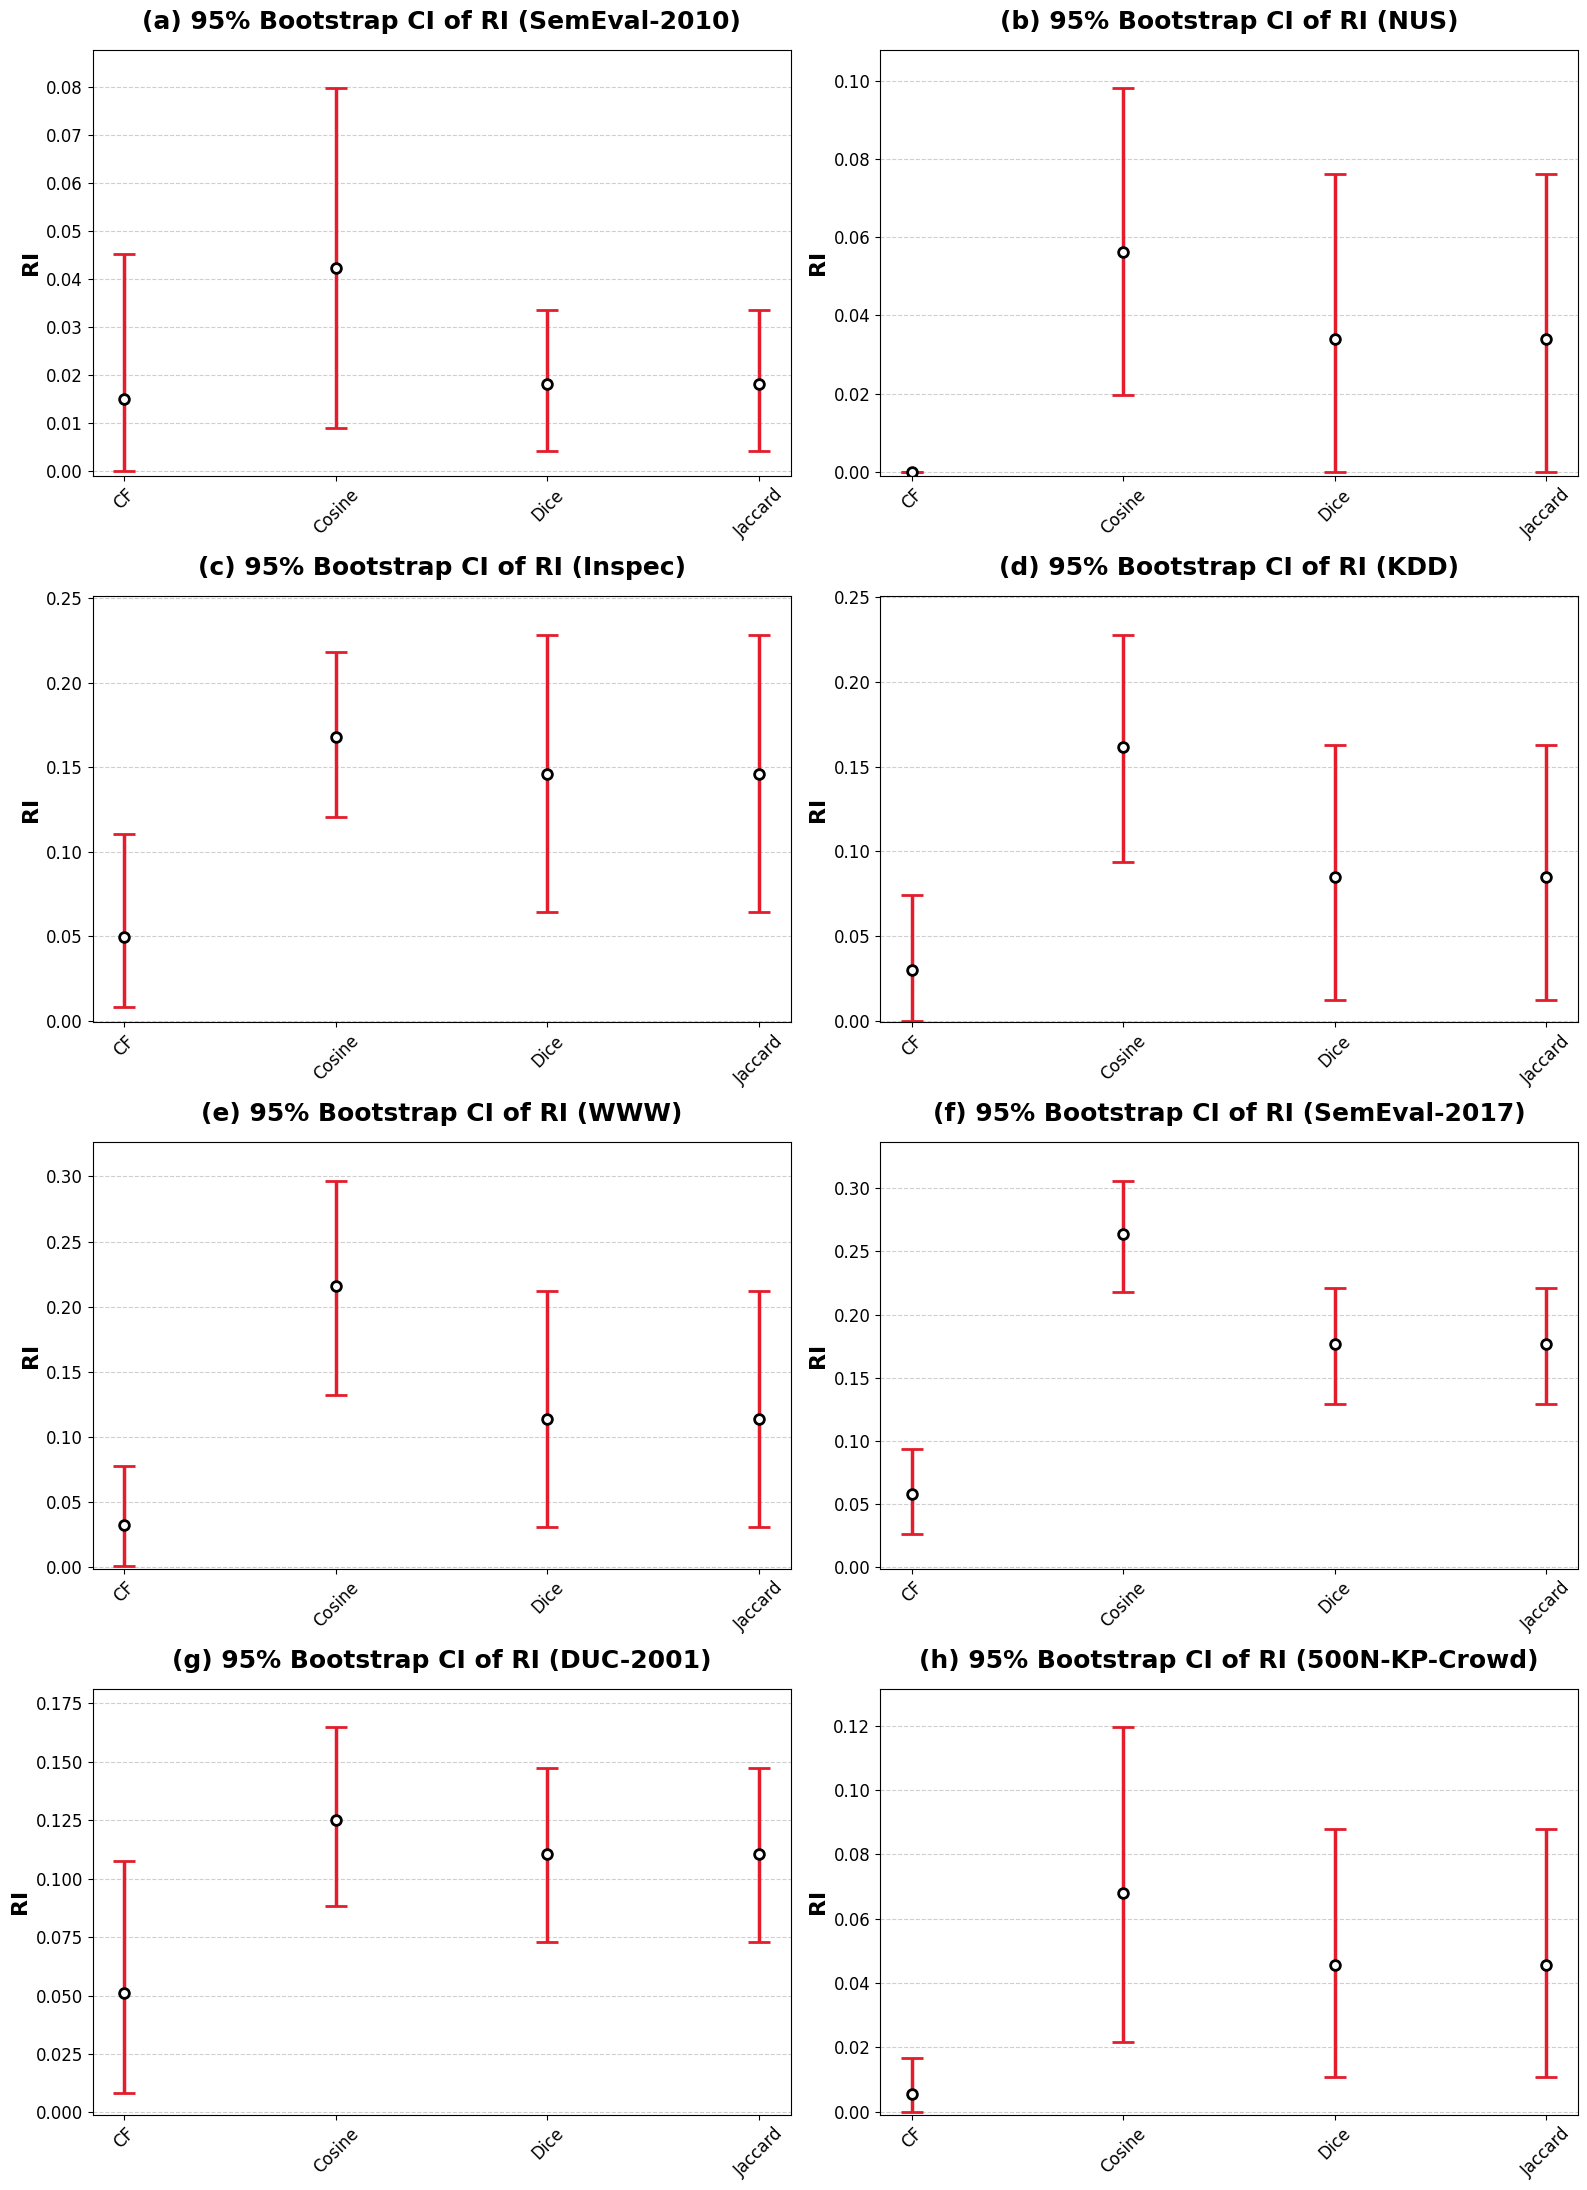

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes_flat = axes.flatten()

for i, ds_name in enumerate(dataset_order):
    instance = ci_df[ci_df['Dataset'] == ds_name]
    current_max = instance['CI Upper'].max()

    ax = axes_flat[i]
    ax.tick_params(axis='x', rotation=45, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_ylim(-0.001, current_max * 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    yerr = [instance['Original Mean'] - instance['CI Lower'], instance['CI Upper'] - instance['Original Mean']]

    ax.errorbar(x=instance['Measure'], y=instance['Original Mean'], yerr=yerr,
                fmt='o', color='black', ecolor='#E31D2B', capsize=8,
                elinewidth=2.5, mfc='white', ms=7, mew=2)

    ax.set_title(f"({alphabet[i]}) 95% Bootstrap CI of RI ({ds_name})", fontsize=18, fontweight='bold', pad=15)
    ax.set_ylabel("RI", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# Correlation Analysis

In [ ]:
def calculate_correlation_coefficient(df, x, y, z=None, method='general', ci=95, n_boot=10000, seed=2026):

    def calculate_rho(df):
        r_xy = stats.spearmanr(df[x], df[y])[0]
        if method == 'general' or z is None:
            return r_xy

        r_xz = stats.spearmanr(df[x], df[z])[0]
        r_yz = stats.spearmanr(df[y], df[z])[0]
        numerator = r_xy - (r_xz * r_yz)

        if method == 'partial':
            denominator = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
        elif method == 'semi-x':
            denominator = np.sqrt(1 - r_xz**2)
        elif method == 'semi-y':
            denominator = np.sqrt(1 - r_yz**2)
        else:
            return r_xy

        return numerator / denominator

    rng = np.random.default_rng(seed)
    rho = calculate_rho(df)
    ci=ci
    n = len(df)
    resampled_rhos = []
    indices = np.arange(n)

    for i in range(n_boot):
        boot_indices = rng.choice(indices, size=n, replace=True)
        resample = df.iloc[boot_indices]
        resampled_rhos.append(calculate_rho(resample))

    resampled_rhos = np.array(resampled_rhos)

    lower = np.percentile(resampled_rhos, (100 - ci) / 2)
    upper = np.percentile(resampled_rhos, 100 - (100 - ci) / 2)

    degree_of_freedom = n - 3 if method == 'general' else n - 4
    se = 1 / np.sqrt(degree_of_freedom)
    r_clipped = np.clip(rho, -0.99999999, 0.99999999)
    z_value = np.arctanh(r_clipped)
    z_score = z_value / se
    p_val = stats.norm.sf(np.abs(z_score)) * 2

    alpha = 0.05
    critical_value = stats.norm.ppf(1 - alpha/2)

    current_z = np.abs(z_score)
    upper_power = 1 - stats.norm.cdf(critical_value, loc=current_z)
    lower_power = stats.norm.cdf(-critical_value, loc=current_z)
    power = upper_power + lower_power

    analysis_name = {
        'general': 'General',
        'partial': 'Partial (X.Z, Y.Z)',
        'semi-x': 'Semi-partial (X.Z)',
        'semi-y': 'Semi-partial (Y.Z)'
    }[method]

    return {
        'Analysis': analysis_name,
        'X': x, 'Y': y, 'Z': z,
        'Spearman': round(rho, 3),
        '95% Bootstrap CI': (round(lower, 3), round(upper, 3)),
        'p-value': f"{p_val:.3e}",
        'Power': round(power, 3)
    }

In [ ]:
results = []

results.append(calculate_correlation_coefficient(Edge_Weighting_results, 'RI', 'IP1', method='general'))
results.append(calculate_correlation_coefficient(Edge_Weighting_results, 'RI', 'IP2', method='general'))
results.append(calculate_correlation_coefficient(Edge_Weighting_results, 'IP1', 'IP2', method='general'))
results.append(calculate_correlation_coefficient(Edge_Weighting_results, 'RI', 'IP1', z='IP2', method='partial'))
results.append(calculate_correlation_coefficient(Edge_Weighting_results, 'RI', 'IP2', z='IP1', method='partial'))
results.append(calculate_correlation_coefficient(Edge_Weighting_results, 'IP1', 'IP2', z='RI', method='partial'))
results.append(calculate_correlation_coefficient(Edge_Weighting_results, 'RI', 'IP1', z='IP2', method='semi-x'))
results.append(calculate_correlation_coefficient(Edge_Weighting_results, 'RI', 'IP2', z='IP1', method='semi-x'))
results.append(calculate_correlation_coefficient(Edge_Weighting_results, 'RI', 'IP1', z='IP2', method='semi-y'))
results.append(calculate_correlation_coefficient(Edge_Weighting_results, 'RI', 'IP2', z='IP1', method='semi-y'))
results.append(calculate_correlation_coefficient(Edge_Weighting_results, 'IP1', 'IP2', z='RI', method='semi-x'))
results.append(calculate_correlation_coefficient(Edge_Weighting_results, 'IP1', 'IP2', z='RI', method='semi-y'))

correlation_analysis = pd.DataFrame(results)
correlation_analysis

,Analysis,X,Y,Z,Spearman,95% Bootstrap CI,p-value,Power
0,General,RI,IP1,None,0.914,"(0.892, 0.929)",3.961e-141,1.000
1,General,RI,IP2,None,0.874,"(0.841, 0.899)",2.762e-107,1.000
2,General,IP1,IP2,None,0.904,"(0.861, 0.936)",1.263e-130,1.000
3,"Partial (X.Z, Y.Z)",RI,IP1,IP2,0.597,"(0.496, 0.682)",4.337e-29,1.000
4,"Partial (X.Z, Y.Z)",RI,IP2,IP1,0.276,"(0.138, 0.407)",4.094e-06,0.996
5,"Partial (X.Z, Y.Z)",IP1,IP2,RI,0.532,"(0.353, 0.692)",5.894e-22,1.000
6,Semi-partial (X.Z),RI,IP1,IP2,0.255,"(0.18, 0.337)",2.209e-05,0.989
7,Semi-partial (X.Z),RI,IP2,IP1,0.118,"(0.052, 0.195)",5.398e-02,0.487
8,Semi-partial (Y.Z),RI,IP1,IP2,0.290,"(0.229, 0.353)",1.250e-06,0.998
9,Semi-partial (Y.Z),RI,IP2,IP1,0.112,"(0.057, 0.167)",6.813e-02,0.446


# Friedman Test & Nemeiny Posthoc Test

In [ ]:
!pip install scikit-posthocs

In [ ]:
import scikit_posthocs as sp

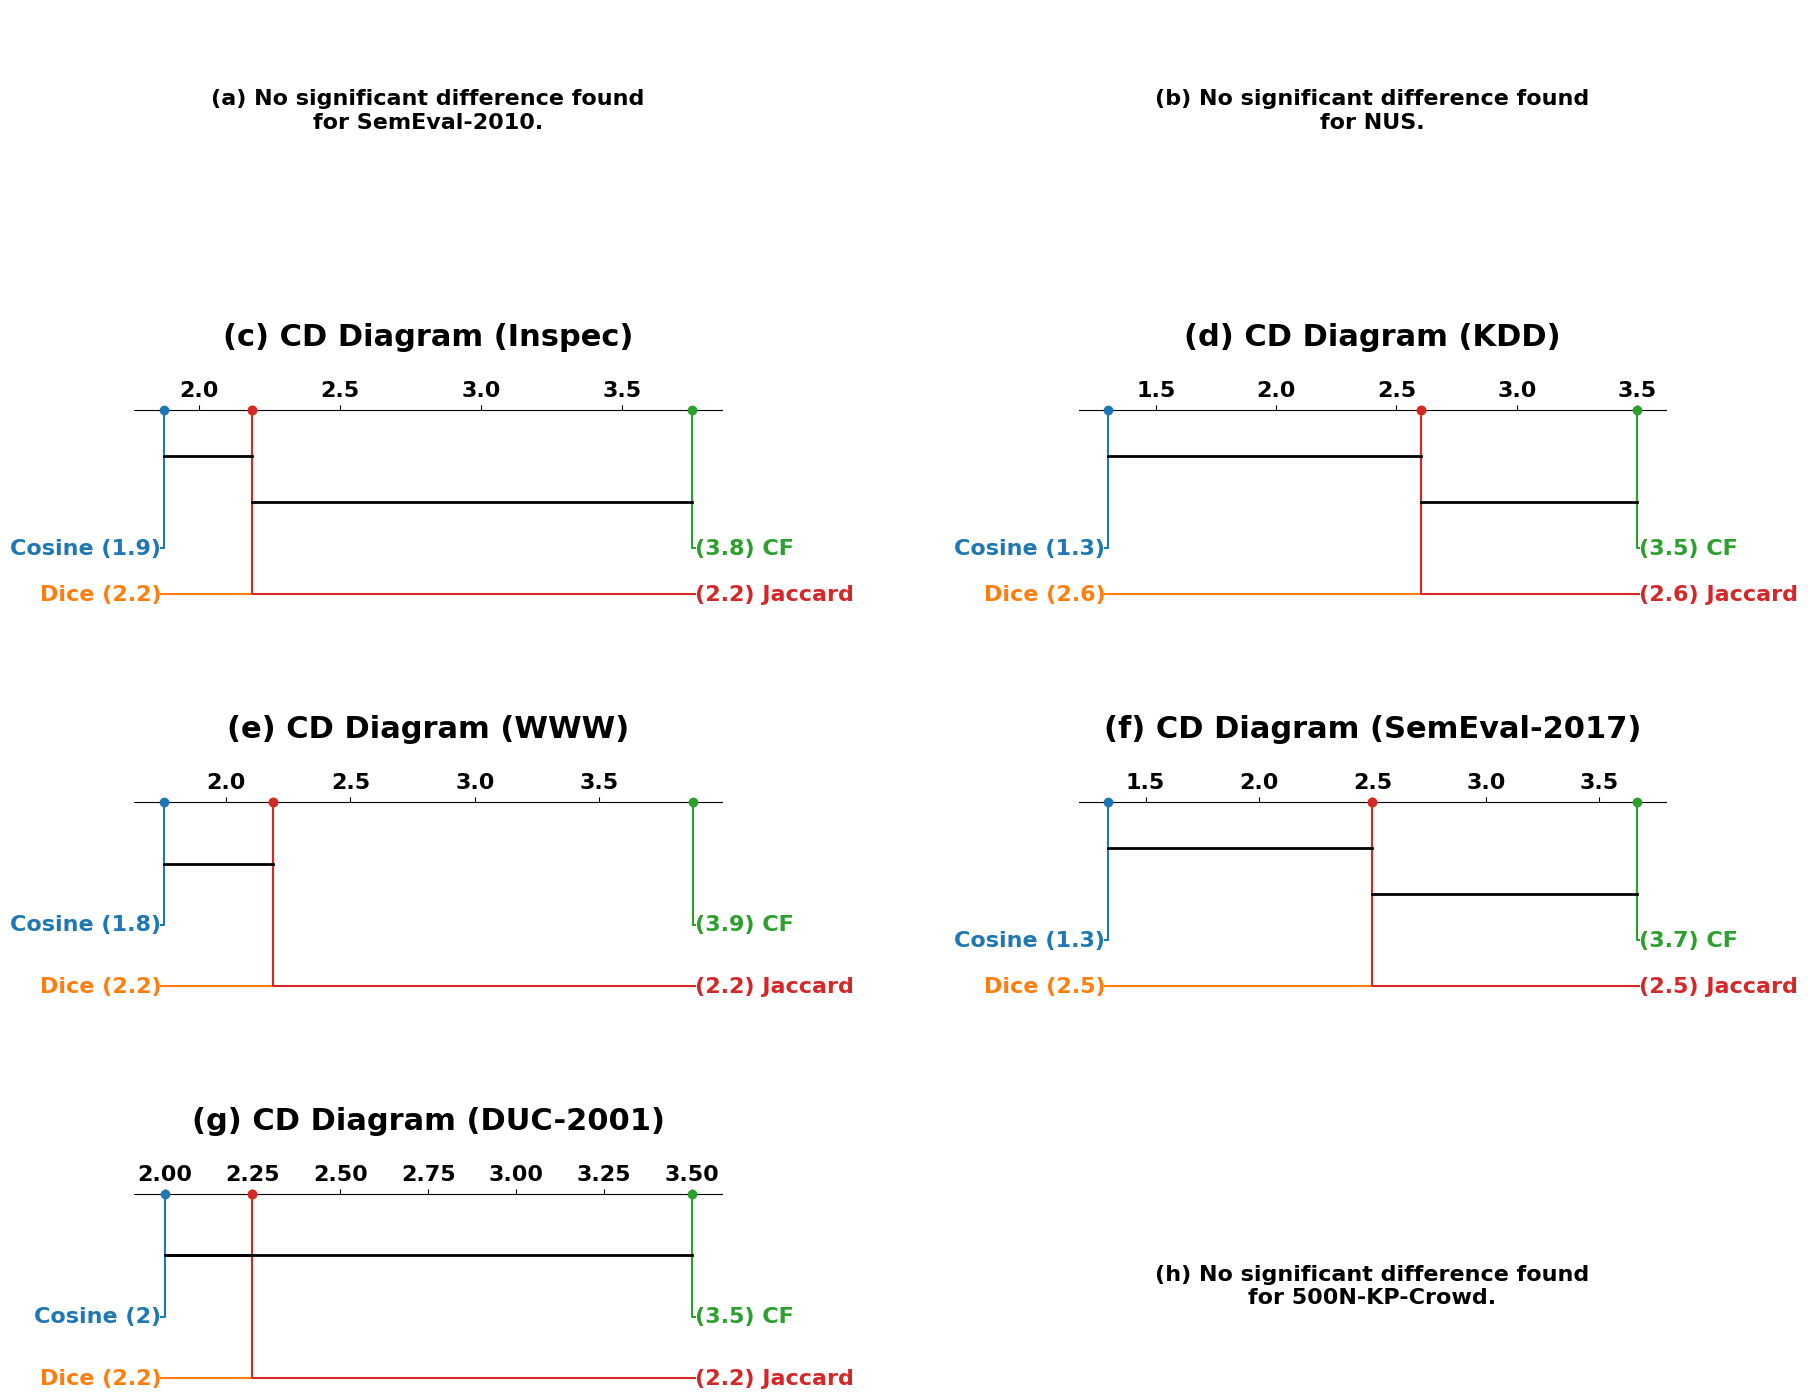

In [ ]:
friedman_results = []
posthoc_matrices = {}

fig, axes = plt.subplots(4, 2, figsize=(20, 16))
axes_flat = axes.flatten()

plt.rcParams.update({
    'axes.titleweight': 'bold',
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'font.size': 16,
    'xtick.labelsize': 16
})

for i, ds_name in enumerate(dataset_order):
    ax = axes_flat[i]

    group = Edge_Weighting_results[Edge_Weighting_results['Dataset'] == ds_name].pivot(
        index='Method', columns='Measure', values='RI'
    )

    measures = group.columns.tolist()

    stat, p_val_legacy = stats.friedmanchisquare(*[group[m] for m in measures])

    n = len(group)
    k = len(measures)

    f_stat = ((n - 1) * stat) / (n * (k - 1) - stat)
    p_val = stats.f.sf(f_stat, k - 1, (k - 1) * (n - 1))

    friedman_results.append({
        'Dataset': ds_name,
        'Friedman Stat': stat,
        'p-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

    if p_val < 0.05:
        posthoc_df = sp.posthoc_nemenyi_friedman(group)
        posthoc_matrices[ds_name] = posthoc_df

        group_rank_df = group.rank(axis=1, ascending=False)
        group_avg_ranks = group_rank_df.mean()

        plt.sca(ax)
        sp.critical_difference_diagram(group_avg_ranks, posthoc_df)

        ax.set_title(f"({alphabet[i]}) CD Diagram ({ds_name})",
                    pad=40, fontsize=22, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f"({alphabet[i]}) No significant difference found\nfor {ds_name}.",
                ha='center', va='center', fontsize=16)
        ax.axis('off')

plt.tight_layout(pad=5.0)

plt.show()

plt.rcdefaults()

friedman_df = pd.DataFrame(friedman_results)

In [ ]:
friedman_df

,Dataset,Friedman Stat,p-value,Significant
0,SemEval-2010,3.731707,3.042157e-01,No
1,NUS,6.954545,6.158212e-02,No
2,Inspec,11.956522,1.997146e-03,Yes
3,KDD,22.363636,3.535643e-08,Yes
4,WWW,14.739130,1.384439e-04,Yes
5,SemEval-2017,16.333333,4.641166e-05,Yes
6,DUC-2001,7.333333,4.964173e-02,Yes
7,500N-KP-Crowd,7.235294,5.252086e-02,No


In [ ]:
posthoc_matrices['KDD']

,CF,Cosine,Dice,Jaccard
CF,1.000000,0.000799,0.402376,0.402376
Cosine,0.000799,1.000000,0.109611,0.109611
Dice,0.402376,0.109611,1.000000,1.000000
Jaccard,0.402376,0.109611,1.000000,1.000000


# Sankey Diagram

In [ ]:
import plotly.graph_objects as go

In [ ]:
Edge_Weighting_results['Outcome'] = Edge_Weighting_results['RI'].apply(
    lambda x: 'RI > 0 (Success)' if x > 0 else 'RI = 0 (Failure)'
)

def create_sankey(df, categories):
    nodes = []
    for category in categories:
        nodes.extend([str(value) for value in df[category].unique()])
    nodes = list(dict.fromkeys(nodes))

    source, target, value, colors, hover_text = [], [], [], [], []

    SUCCESS_COLOR = "rgba(0, 98, 155, 0.45)"
    FAILURE_COLOR = "rgba(229, 9, 20, 0.45)"

    for i in range(len(categories) - 1):
        c1 = categories[i]
        c2 = categories[i+1]

        group_cols = list(dict.fromkeys([c1, c2, 'Outcome']))
        flow = df.groupby(group_cols).size().reset_index(name='flow_count')
        totals = df.groupby(c1).size().to_dict()

        for j, row in flow.iterrows():
            src_idx = nodes.index(str(row[c1]))
            tgt_idx = nodes.index(str(row[c2]))
            val = row['flow_count']
            outcome = row['Outcome']

            percentage = (val / totals[row[c1]]) * 100

            source.append(src_idx)
            target.append(tgt_idx)
            value.append(val)

            if 'Success' in str(outcome):
                colors.append(SUCCESS_COLOR)
            else:
                colors.append(FAILURE_COLOR)

            hover_text.append(f"Fate: {outcome}<br>Count: {val}<br>Ratio: {percentage:.1f}%")

    return nodes, source, target, value, colors, hover_text

In [ ]:
path_columns = ['Dataset', 'Method', 'Measure', 'Outcome']
nodes, source, target, value, colors, hover_text = create_sankey(Edge_Weighting_results, path_columns)

fig = go.Figure(data=[go.Sankey(
    arrangement = "perpendicular",
    node = dict(
      pad = 30, thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = nodes,
      color = "lightgrey"
    ),
    link = dict(
      source = source,
      target = target,
      value = value,
      color = colors,
      customdata = hover_text,
      hovertemplate = '<b>%{source.label} → %{target.label}</b><br>%{customdata}<extra></extra>'
    )
)])

fig.update_layout(
    title_text="<b>Which Pipelines Yield RI-Computable Semantic Networks?</b>",
    font_size=24, width=1200, height=800
)

fig.show()

# Case Studies

In [ ]:
def case_studies(df_results, graph_dict, null_graph_dict, cases):
    alphabet = list(string.ascii_lowercase)
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    for row_idx, (ds, mt, ms) in enumerate(cases):
        ri_value = df_results[
            (df_results['Dataset'] == ds) &
            (df_results['Method'] == mt) &
            (df_results['Measure'] == ms)
        ]['RI'].values[0]

        G_orig = graph_dict[ds][mt][ms]
        G_null = null_graph_dict[ds][mt][ms]
        t_orig, l_orig = nx.transitivity(G_orig), nx.average_shortest_path_length(G_orig)
        t_null, l_null = nx.transitivity(G_null), nx.average_shortest_path_length(G_null)

        pos_orig = nx.kamada_kawai_layout(G_orig)
        pos_null = nx.kamada_kawai_layout(G_null)

        idx_orig = row_idx * 2
        idx_null = row_idx * 2 + 1

        ax_orig = axes[row_idx, 0]
        nx.draw(G_orig, pos_orig, ax=ax_orig, with_labels=True,
                node_color='#A0CBE8', edge_color='#CCCCCC', node_size=600,
                font_size=9, width=1.5)
        ax_orig.set_title(f"({alphabet[idx_orig]}) Case #{row_idx+1} Original SN ({ds} - {mt} - {ms})\n"
                          f"T={t_orig:.4f} | L={l_orig:.4f} | RI={ri_value:.4f}", fontsize=16, fontweight='bold')

        ax_null = axes[row_idx, 1]
        nx.draw(G_null, pos_null, ax=ax_null, with_labels=True,
                node_color='#FF9896', edge_color='#CCCCCC', node_size=600,
                font_size=9, width=1.5)
        ax_null.set_title(f"({alphabet[idx_null]}) Case #{row_idx+1} Null Model ({ds} - {mt} - {ms})\n"
                          f"T={t_null:.4f} | L={l_null:.4f}", fontsize=16, fontweight='bold')

    plt.suptitle(f"Topological Cues of RI: Case Studies of Rigid versus Flexible SNs", fontsize=22, y=0.98, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

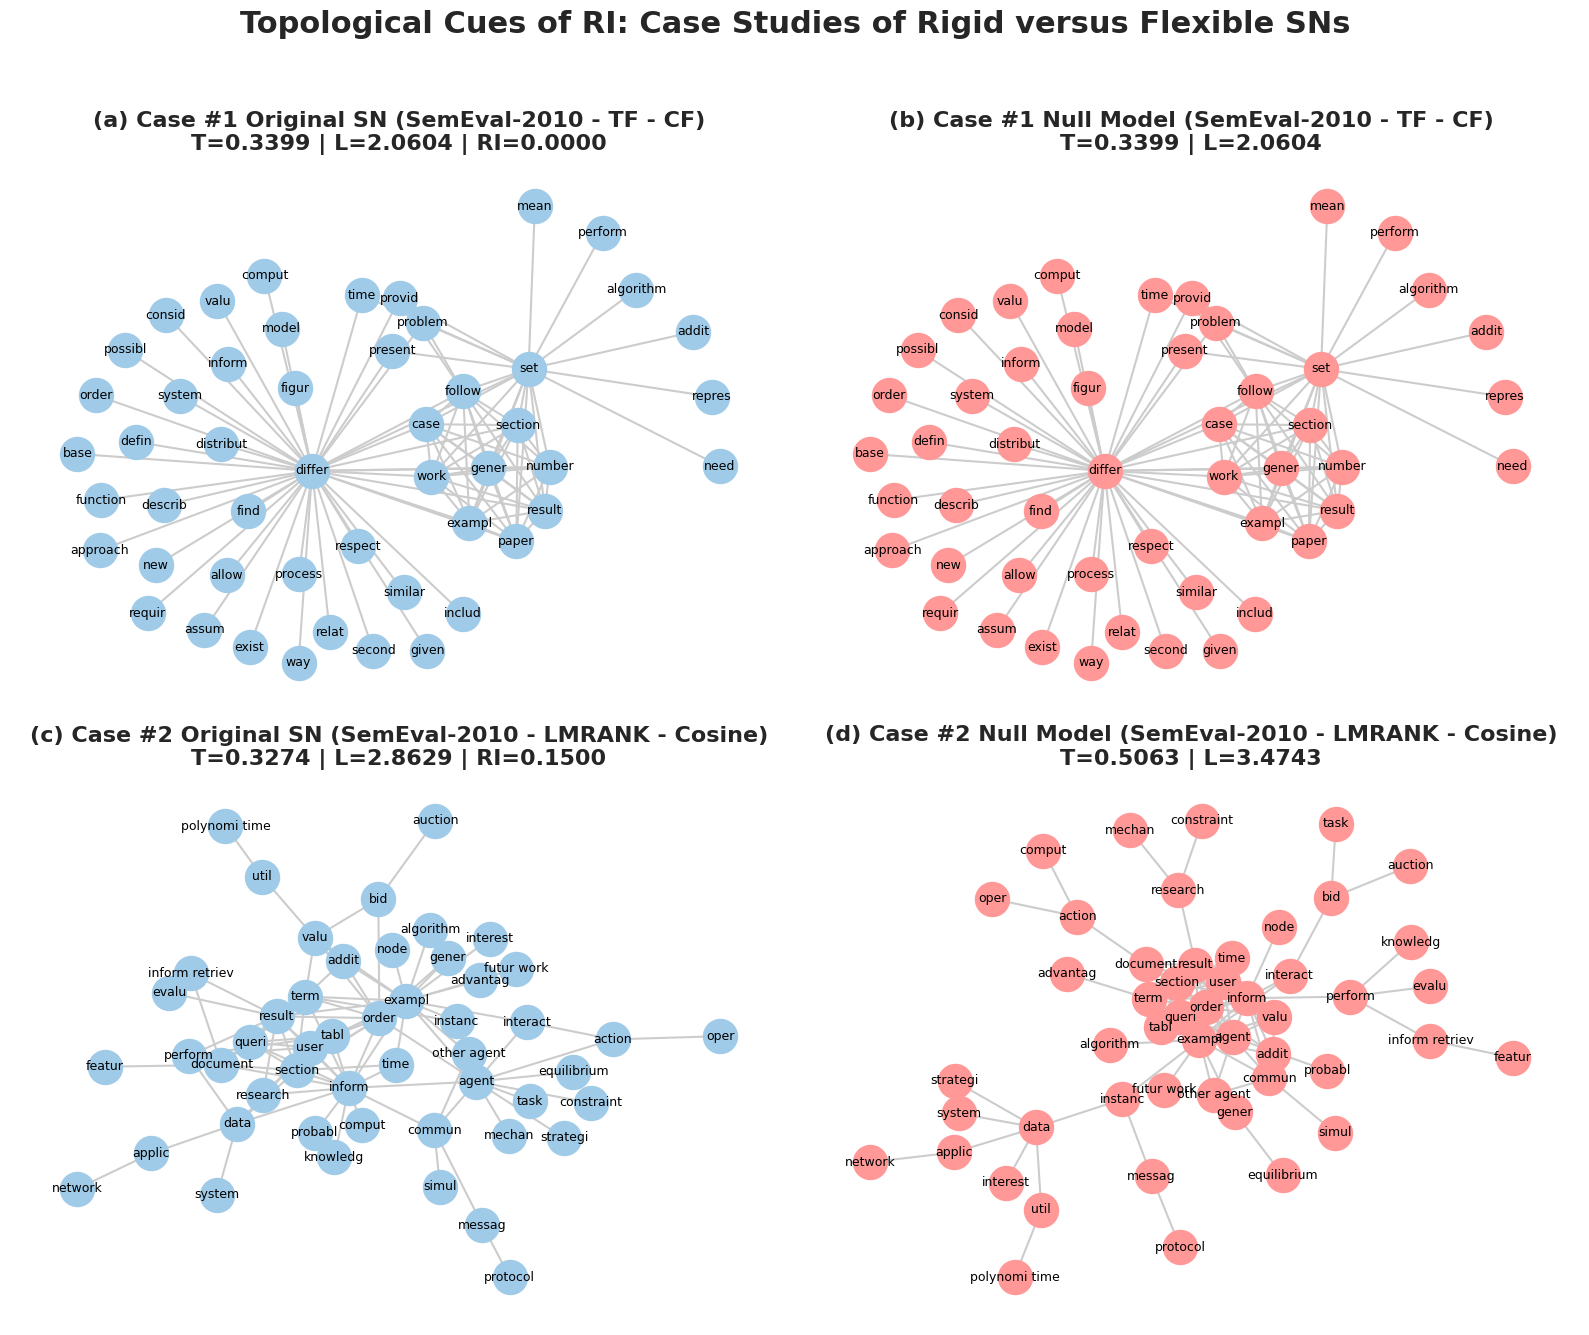

In [ ]:
target_cases = [
    ('SemEval-2010', 'TF', 'CF'),
    ('SemEval-2010', 'LMRANK', 'Cosine')
]

case_studies(Edge_Weighting_results, Graph_dict, Null_Graph_dict, target_cases)

# Extract Requirements

In [ ]:
!pip freeze Edge_Weighting.txt

In [ ]:
with open('Edge_Weighting_results.pkl', 'rb') as f:
    Edge_Weighting_results = pickle.load(f)